- cloudy ml: https://www.youtube.com/watch?v=fGsl2kMzNPg&t=5125s
- DAX part1: https://www.youtube.com/watch?v=2nMZuWdX9Zw&t=1794s
- DAX part2: https://www.youtube.com/watch?v=dbS8HP-DArY&list=WL&index=210&t=111s

- Complete process: https://youtu.be/G8ikAJele_s?si=r2uGnu8rX_t4uUgc
- liked table formatting: https://youtu.be/vkUXAKqbEjY?si=OJBJK0d9kRQ9BUaA
- Satish Dhawle: https://youtu.be/znJGWMtk_EE?si=T4IEfF0AobiwQgaA

- Dashboard playlist: https://youtube.com/playlist?list=PLO9LeSU_vHCWUvkE1FrGeNxSve7YtJrYl&si=HeOjx_zhoGXDzuhG

- Data Modelling: https://www.youtube.com/watch?v=JQ9wX1d7dGE
- Data Cleaning: https://www.youtube.com/watch?v=AWcmiyra7qs
- Interview Questions: https://youtube.com/playlist?list=PLO9LeSU_vHCUAh-OkfoKUx6PlNJHAxgCK&si=bPlfPqr-9W5V8SQY
- Power Query: https://www.youtube.com/watch?v=VsHHbhUWq9U&t=248s, For Data Cleaning: https://www.youtube.com/watch?v=HSwPvqkbjOE 

# DAX(Data Analysis Expression) Formula

**Syntax:** `Measure = FORMULA(Parameter)`

- In DAX, when referring to a column, it's best practice to use the table name in single quotes(`''`) if the table name contains spaces or special characters.
- Example: `'Sales'[Sales Amount]`
- If the table name does not have spaces or special characters, quotes are optional.
- Column names must be enclosed in square brackets [Sales Amount].

`Sales Category = IF(Sales[Sales Amount] > 500, "High", "Low")` This will still work, but using single quotes for table names is a good habit to avoid errors in complex DAX expressions.

## Mathematical functions

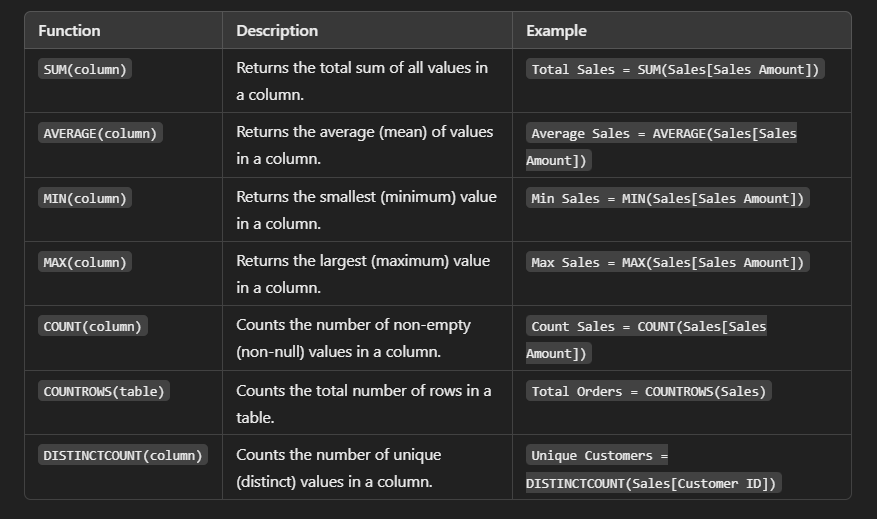

### DISTINCT
The DISTINCT function in DAX is used to return a unique list of values from a column or a table. This is particularly useful when you want to remove duplicates and work with distinct values only.

**Syntax:** `DISTINCT(<column_or_table>)`

- column_or_table → The column or table from which to return unique values.

**✅ Includes blank as a distinct value.**

In [ ]:
# CustomerName: John, Alice, John, Bob, (blank)

Unique_Customers = DISTINCT(Sales[CustomerName])

# Output: John, Alice, Bob, (blank)


In [ ]:
# Count Unique Customers

# Customer ID: 101, 102, 101, 103, 102

UniqueCustomers = COUNTROWS(DISTINCT(Sales[Customer ID]))

# Output: 3


In [ ]:
# Product ID: 101, 102, 101, 103, 102
# Sales: 200, 150, 100, 300, 50

TotalSalesByUniqueProducts = 
CALCULATE(
    SUM(Sales[Sales]),
    DISTINCT(Sales[Product ID])
)

# Output: 650


### DISTINCTCOUNT

- DISTINCTCOUNT returns the number of unique (distinct) values in a column.
- DISTINCTCOUNT ignores blank values by default.

👉 Instead of giving a table (like DISTINCT does), DISTINCTCOUNT gives a single number — the count of distinct items.

**Syntax:** `DISTINCTCOUNT(<column>)`

- `<column>`: The specific column from which you want to count the unique values.

In [ ]:
# CustomerName: John, Alice, John, Bob, (blank)

Distinct_Customer_Count = DISTINCTCOUNT(Sales[CustomerName]) # ignores blank values

# Output: 3 (John, ALice, Bob)


### VALUES
- VALUES() returns a distinct list of values from a column while respecting the current filters.

- It behaves similar to `DISTINCT()`, but with a key difference: it can also return a blank row if the column contains it — even when filters are applied.

**Syntax:** `VALUES(column_or_table)`

- column_or_table – The column or table from which unique values should be returned.

The output depends on where VALUES is used:

- On a column → Returns distinct (unique) visible values from the column, based on the current filter context.
- On a table → Returns the filtered version of the table; if only one row is visible after filtering, returns that single row; otherwise, returns all visible rows.
- When no data exists → Returns an empty table (sometimes shows a blank row in visuals to represent "no data").
- When used in a measure → Filter context (slicers, page filters, visuals) affects the output dynamically.

**📘 How It Works**
- If no filter is applied, VALUES(column) returns all distinct values from the column (similar to DISTINCT but filter-aware).

- If filters are applied, VALUES(column) returns only visible (filtered) unique values.

- If used on a table (VALUES(table)), it returns the filtered version of the table — only rows visible in current context.

- If multiple values exist in the current context (inside a measure or calculated column), VALUES(column) returns a table with all visible values, while SELECTEDVALUE(column) tries to return a single value (or a fallback).


In [ ]:
# Category: Electronics, Furniture, Electronics, Clothing, (blank)

UniqueCategories = VALUES(Products[Category])

# Output: Electronics, Furniture, Clothing, (blank)


In [ ]:
# If VALUES is used in a measure inside a visual, it returns a single value when filtered.

# Category: Electronics, Furniture, Electronics, Clothing, (blank)

SelectedCategory = VALUES(Products[Category])

# Output: (Depends on the current filter context, e.g., if "Electronics" is selected)
# Output: Electronics (if "Electronics" is selected)

In [ ]:
# You can use VALUES inside IF to check if a user selected a single value.

# Category: Electronics, Furniture, Electronics, Clothing, (blank)

CategoryCheck = 
IF(COUNTROWS(VALUES(Products[Category])) = 1, "Single Category Selected", "Multiple Categories")

# Output: Single Category Selected


# In DAX we don't use == for comparison, instead we use = only

- ✔️ To get unique values from a column for slicers or filters.
- ✔️ To check if a single value is selected in measures.
- ✔️ To use inside CALCULATE for conditional filtering.

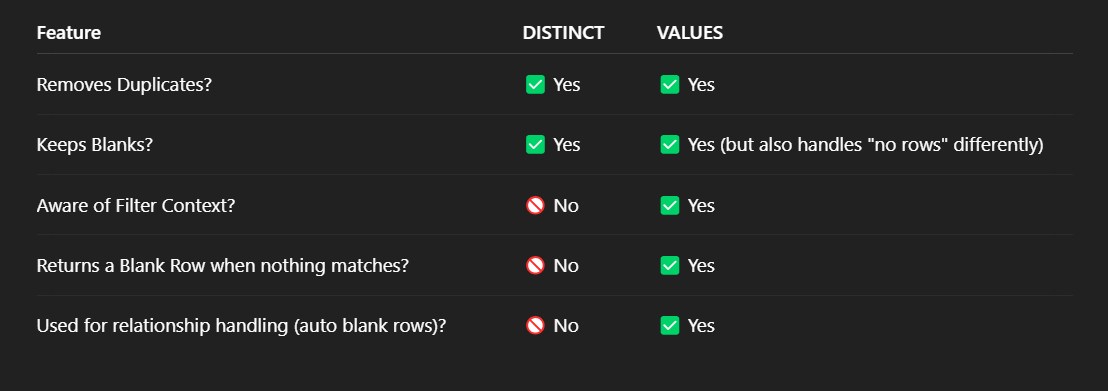

<br>

Let's say we have `CustomerName` column that have values: John, Alice, John, Bob, Alice, (Blank):
- Now If I use `E1 = DISTINCT(Sales[CustomerName])` then it will return John, Alice, Bob, (Blank)
- Now If I use `E2 = VALUES(Sales[CustomerName])` then it will also return same result i.e. John, Alice, Bob, (Blank)

BUT — if you add a filter (example: Region = "East", `FILTER ( Sales, Sales[Region] = "East" )`) and no matching rows, then: 
- `VALUES()` will return a single blank row if no records match.
- `DISTINCT()` would return an empty table (no rows).

<hr>

**🧠 Quick Tip**
- Use DISTINCT() if you just need a simple list of unique values.
- Use VALUES() when you care about filter context, relationships, and slicer interactions.



### COUNT

COUNT() function in DAX is used to count the number of numeric values or date/time values in a column, ignoring any blank values.

- It counts only numeric (integer or decimal) values in a column and date/time columns.
- It ignores text or blank values.

**Syntax:** `COUNT(<column>)`

In [ ]:
# SalesAmount: 200, 150, (blank), 300, "Text"

ProductCount = COUNT(Sales[SalesAmount])

# Output: 3


### COUNTA
Counts the number of non-blank (non-empty) values in a specified column. Works on text, numbers, logical values, and dates.

**Syntax:** `COUNTA(column)`


In [ ]:
# Customer Name: John, Alice, John, Bob, (blank)

TotalCustomers = COUNTA(Sales[Customer Name])

# Output: 4

### COUNTX
- Iterates over a table and evaluates an expression for each row.
- Counts the number of non-blank results from the expression.
- Unlike COUNTA, it can apply calculations on each row.
    
**Syntax:** `COUNTX(table, expression)`

In [ ]:
# Amount: 100, 200, 300, (blank), 150

TotalValidOrders = COUNTX(Sales, Sales[Amount] * 2)

# Output: 4

# If Amount column contains any blank rows, those are ignored.

### COUNTAX
- Similar to COUNTX, but it works on any data type (text, numbers, dates).
- COUNTX mainly works with numeric expressions, whereas COUNTAX works on any expression.

**Syntax:** `COUNTAX(table, expression)`


In [ ]:
# Customer Name: John, Alice, John, Bob, (blank)

TotalNonEmptyCustomers = COUNTAX(Sales, Sales[Customer Name])

# Output: 4


# Counts non-blank customer names in the Sales table.
# If Customer Name contains blank values, they will be ignored.

### COUNTBLANK
Counts the number of blank (empty) values in a column.
Works for text, numbers, and date columns.
    
**Syntax:** `COUNTBLANK(column)`


In [ ]:
# Customer Name: John, Alice, John, Bob, (blank)

TotalMissingNames = COUNTBLANK(Sales[Customer Name])

# Output: 1

# If Customer Name column has 1 blank value, the result will be 1.

### BLANK
The BLANK() function in DAX (Data Analysis Expressions) is used to return a blank (empty) value. It is often used when handling missing data, NULL values, or replacing values with blank.

**Syntax:** `BLANK()`

In [ ]:
# Handling Missing Data (Replacing with Blank)

# Amount: 100, 0, 300, 0, 150

SalesStatus = IF(Sales[Amount] = 0, BLANK(), "Valid Sale")

# Output: Valid Sale, (blank), Valid Sale, (blank), Valid Sale


In [ ]:
# Avoiding Division by Zero (Preventing Errors)

# Revenue: 1000, 0, 3000, 500, 0
# Profit: 200, 0, 1200, 300, 0

ProfitMargin = IF(Sales[Revenue] = 0, BLANK(), Sales[Profit] / Sales[Revenue])

# Output: 0.2, (blank), 0.4, 0.6, (blank)


In [ ]:
# Using BLANK() in Measures
TotalDiscount = SUM(Sales[Discount])
# If there are no discounts applied, the result is usually 0, but you can force it to show a blank:

# Discount: 10, 20, 0, 30, 0

TotalDiscount = IF(SUM(Sales[Discount]) = 0, BLANK(), SUM(Sales[Discount]))

# Output: 60, (blank)



## Logical Functions

### IF 
The IF function evaluates a condition and returns one value if true and another if false.

**Syntax:** `IF(condition, true_value, false_value)`

- condition: A logical test (e.g., Sales[Sales Amount] > 500)
- true_value: The value returned if the condition is TRUE
- false_value: The value returned if the condition is FALSE- 

In [ ]:
# Let's say we want to categorize sales as "High" if above 500 and "Low" otherwise.
Sales Category = IF(Sales[Sales Amount] > 500, "High", "Low")

### SWITCH 
The SWITCH function works like a case statement. It evaluates an expression and returns a corresponding result.

**Syntax:** `SWITCH(expression, value1, result1, value2, result2, ..., else_result)`
- expression: The value to evaluate
- value1, result1: If the expression matches value1, return result1
- else_result: The default result if no match is found


In [ ]:
# Let's classify ship modes based on their names.
Shipping Category = SWITCH(
    Sales[Ship Mode], 
    "Standard Class", "Slow",
    "Second Class", "Moderate",
    "First Class", "Fast",
    "Same Day", "Very Fast",
    "Unknown"
)


### CHOOSE

- CHOOSE function returns a value from a list of values based on an index number you specify.
- If the index is out of range, it returns blank.

It's like picking the Nth item from a set of options.

**Syntax:** `CHOOSE(index, value1, value2, value3, ..., valueN)`

- index: A number (usually an integer) that tells DAX which value to return.
- value1, value2, ..., valueN: The list of possible values to pick from.

In [ ]:
# Index Number: 1, 2, 3

SelectedColor = CHOOSE([Index Number], "Red", "Green", "Blue")

# Output: Red, Green, Blue


In [ ]:
Quarter Name = CHOOSE([Quarter], "Q1", "Q2", "Q3", "Q4")

# If Quarter = 1, returns Q1
# If Quarter = 2, returns Q2, etc.

In [ ]:
Priority Label = 
CHOOSE(
    SELECTEDVALUE('Tasks'[Priority]), 
    "High", 
    "Medium", 
    "Low"
)


### AND 
The AND function checks if both conditions are TRUE.

**Syntax:** `AND(condition1, condition2, condition....n)`

- Returns TRUE if both condition1 and condition2 are TRUE.
- Returns FALSE if any one condition is FALSE.

In [ ]:
# Check if Sales Amount is above 500 AND Discount is less than 10%.
High Profit Sale = IF(AND(Sales[Sales Amount] > 500, Sales[Discount] < 0.10), "Profitable", "Not Profitable")

In [ ]:
# Check if the sales are above 500, the discount is less than 10%, and the region is "East".
High Profit Sale = IF(AND(Sales[Sales Amount] > 500, Sales[Discount] < 0.10, Sales[Region] = "East"), "Profitable", "Not Profitable")

### OR 
The OR function checks if at least one condition is TRUE.

**Syntax:** `OR(condition1, condition2, condition....n)`

- Returns TRUE if any one condition is TRUE.
- Returns FALSE only if both conditions are FALSE.

In [ ]:
# Check if Sales Amount is above 1000 OR the Discount is greater than 15%.
Special Sale = IF(OR(Sales[Sales Amount] > 1000, Sales[Discount] > 0.15), "Yes", "No")

In [ ]:
# Check if the sales are above 1000, the discount is more than 15%, or the region is "North".
Special Sale = IF(OR(Sales[Sales Amount] > 1000, Sales[Discount] > 0.15, Sales[Region] = "North"), "Yes", "No")

### Using && for AND and || for OR
Instead of AND() and OR(), you can also use:

- `&&` → for AND
- `||` → for OR

In [ ]:
High Profit Sale = IF((Sales[Sales Amount] > 500) && (Sales[Discount] < 0.10) && (Sales[Region] = "East"), "Profitable", "Not Profitable")

In [ ]:
Special Sale = IF((Sales[Sales Amount] > 1000) || (Sales[Discount] > 0.15) || (Sales[Region] = "North"), "Yes", "No")

### NOT Function
The NOT function reverses a condition.

- If TRUE, it returns FALSE.
- If FALSE, it returns TRUE.

**Syntax:** `NOT(condition)`

In [ ]:
# Check if a product is NOT a High Sales product.
Not High Sales = IF(NOT(Sales[Sales Amount] > 500), "Low", "High")

## Text Functions

### CONCATENATE
The CONCATENATE function combines two text values into one.
    
**Syntax:** `CONCATENATE(text1, text2)`

- text1: The first text string.
- text2: The second text string.

**🚨 Limitation:** It can only join two strings at a time. If you need to join multiple values, use `&` or `COMBINEVALUES()`.

In [ ]:
# Join First Name and Last Name into a full name.
Full Name = CONCATENATE(Sales[First Name], Sales[Last Name]) # John Doe

### COMBINEVALUES
The COMBINEVALUES() function joins multiple text values with a specified delimiter.

**Syntax:** `COMBINEVALUES(delimiter, column1, column2, column3, ...)`

- delimiter: The character(s) used between values.
- column1, column2, ...: The text columns to combine.


In [ ]:
# Join First Name, Last Name, and City with a comma.
Full Info = COMBINEVALUES(", ", Sales[First Name], Sales[Last Name], Sales[City]) # John, Doe, New York

**Why use COMBINEVALUES()?**

- More efficient than & for large datasets.
- Handles BLANK() values better.

### LEFT
The LEFT() function returns the first N characters from a text.

**Syntax:** `LEFT(text, number_of_chars)`

- text: The string to extract from.
- number_of_chars: The number of characters to extract from the left.

In [ ]:
# Get the first 3 characters of Product Code.
Product Prefix = LEFT(Sales[Product Code], 3) # "ABC123" → "ABC"

### RIGHT
The RIGHT() function returns the last N characters from a text.

**Syntax:** `RIGHT(text, number_of_chars)`

- text: The string to extract from.
- number_of_chars: The number of characters to extract from the right.

In [ ]:
# Get the last 4 characters of Order ID.
Order Suffix = RIGHT(Sales[Order ID], 4) # "ORD4567" → "4567"

### MID
The MID() function extracts text from the middle of a string, starting at a specific position.
    
**Syntax:** `MID(text, start_position, number_of_chars)`

- text: The string to extract from.
- start_position: The starting position (1-based index).
- number_of_chars: The number of characters to extract.

In [ ]:
# Extract characters 3 to 6 from Order Code.
Order Extract = MID(Sales[Order Code], 3, 4) # "AB12345X" → "1234"

### FIND

FIND function locates the starting position of a substring within a string.
It returns the position number where the substring first appears.

FIND is `case-sensitive` i.e. "abc" and "ABC" are treated differently.

**Syntax:** `FIND(find_text, within_text, [start_num], [not_found_value])`

- find_text:	The text you want to find.
- within_text:	The full text where you want to search.
- start_num (optional):	Where to start searching (default = 1).
- not_found_value (optional):	What to return if text not found (default = error).

**How it Works**
- If find_text is found → returns the position (starting from 1).
- If not found → it throws an error unless you provide not_found_value.

In [ ]:
Position = FIND("PBI", "Learning PBI with DAX") # 10

Position = FIND("a", "Data Analysis", 5) # 8

Position = FIND("SQL", "Power BI DAX", 1, 0) # 0


### SEARCH
The SEARCH() function returns the position of a substring within a text.

SEARCH is `case-insensitive` i.e. "abc" and "ABC" are treated as same.

**Syntax:** `SEARCH(find_text, within_text, start_position, not_found_value)`

- find_text: The text to search for.
- within_text: The text where the search happens.
- start_position (optional): The position to start searching (default = 1).
- not_found_value (optional): The value to return if find_text is not found (default = error).

In [ ]:
# Find the position of "-" in Product Code.
Dash Position = SEARCH("-", Sales[Product Code], 1, -1) # "ABC-123" → 4

### SUBSTITUTE
The SUBSTITUTE() function replaces all occurrences of a substring with a new text.

SUBSTITUTE is `case-sensitive` i.e. "abc" and "ABC" are treated differently.

**Syntax:** `SUBSTITUTE(text, old_text, new_text)`

- text: The original string.
- old_text: The text to replace.
- new_text: The replacement text.

In [ ]:
# Replace "OLD" with "NEW" in Product Name.
Updated Product = SUBSTITUTE(Sales[Product Name], "OLD", "NEW") # "OLD-Model A" → "NEW-Model A"

### REPLACE

REPLACE function replaces part of a string with a new string.
It is based on character position (not on finding specific text like SUBSTITUTE does).

REPLACE is `case-insensitive` i.e. "abc" and "ABC" are treated as same.

**Syntax:** `REPLACE(old_text, start_num, num_chars, new_text)`

- old_text:	The original text string.
- start_num:	The position to start replacing (1-based).
- num_chars:	How many characters to replace.
- new_text:	The text you want to insert.

In [ ]:
New Text = REPLACE("Power BI", 1, 5, "Excel") #  "Excel BI"

Modified = REPLACE("2025-04-28", 6, 2, "12") # "2025-12-28"

New Product Code = 
REPLACE('Products'[ProductCode], 1, 3, "PROD")
# If original = "PRD-1234", new = "PROD-1234"

- `REPLACE`: Replaces text based on a specified position and length.
- `SUBSTITUTE`: Replaces specific occurrences of a substring with another substring.​


### FORMAT
The FORMAT() function in DAX is used to convert a value into a formatted text string using a specified format pattern.

**Syntax:** `FORMAT(value, format_string)`

- value: The number, date, or other value to format.
- format_string: The format pattern (like "DD-MMM-YYYY", "Currency", etc.).

**Returns:** A text string with the formatted value.

#### Formatting Numbers

In [ ]:
Formatted Sales = FORMAT(Sales[Total Sales], "0.00") # "2500.50" (If Total Sales is 2500.5)

In [ ]:
Sales Currency = FORMAT(Sales[Total Sales], "₹#,##0.00") # "₹2,500.50" (For Indian Rupees)

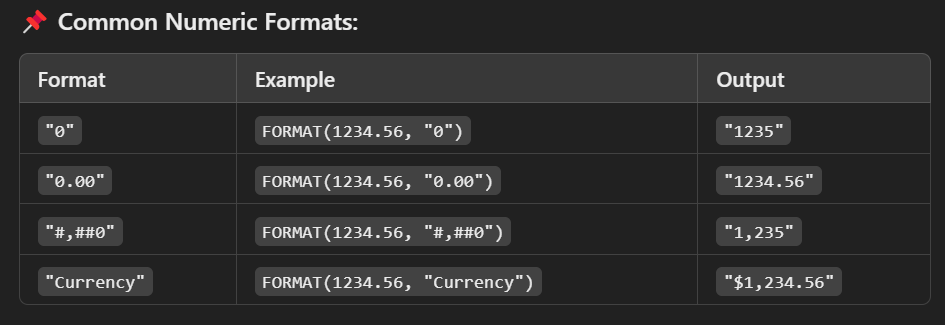

#### Formatting Dates

In [ ]:
Formatted Date = FORMAT(Orders[Order Date], "DD-MMM-YYYY") # "05-Mar-2025"

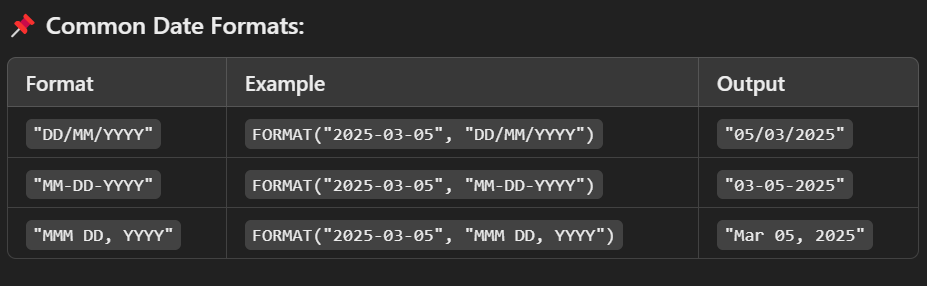

#### Formatting Time

In [ ]:
Formatted Time = FORMAT(NOW(), "HH:MM AM/PM") # "02:30 PM"

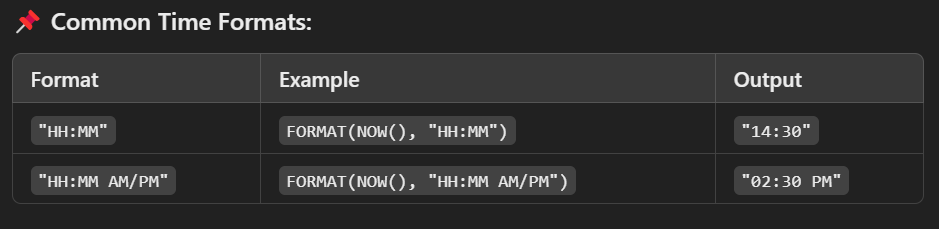

#### Formatting Percentages

In [ ]:
Profit Percentage = FORMAT(Sales[Profit] / Sales[Total Sales], "0.00%") # "12.50%" (If the division result is 0.125)

## Date & Time Functions

### TODAY
The TODAY() function returns the current system date without the time.
    
**Syntax:** `TODAY()`

In [ ]:
Current Date = TODAY() # 2025-03-05

### NOW
The NOW() function returns the current system date and time.

**Syntax:** NOW()``



In [ ]:
Current DateTime = NOW() # 2025-03-05 14:30:25

### DATE
Creates a date value using specified year, month, and day.

**Syntax:** `DATE(Year, Month, Day)`

In [ ]:
DATE(2024, 3, 22) # 22-Mar-2024

### YEAR
The YEAR() function extracts the year from a date.

**Syntax:** `YEAR(date)`

- date: A date column or value.

In [ ]:
Order Year = YEAR(Sales[Order Date]) # 2024

### MONTH
The MONTH() function extracts the month from a date.

**Syntax:** `MONTH(date)`

- date: A date column or value.

In [ ]:
Order Month = MONTH(Sales[Order Date]) # 3 (for March)

# Note: Returns a number between 1 (Jan) to 12 (Dec).

### DAY
The DAY() function extracts the day from a date.

**Syntax:** `DAY(date)`

- date: A date column or value.

In [ ]:
Order Day = DAY(Sales[Order Date]) # 15

`DAY(Sales[Order Date])`: It extracts the day directly (like 1, 2, ..., 31).

However, we can also write: `Sales[Order Date].[Day]`. this syntax usually happens when:

- You're working with an auto-generated Date hierarchy in Power BI.
- Power BI automatically splits the date into: `Year`, `Quarter`, `Month`, `Day`

In that hierarchy, `Sales[Order Date].[Day]` points specifically to the Day part of the hierarchy (like "27" from 2025-04-27).

✅ It's used when you have already expanded a date into Year, Month, Day levels, typically in visuals.

### EOMONTH
The EOMONTH() function returns the end of the month for a given date, with an optional offset.

**Syntax:** `EOMONTH(start_date, months)`

- start_date: The reference date.
- months: Number of months to move forward/backward (use 0 for the same month).

In [ ]:
# Today: 2025-03-15

End of Month = EOMONTH(TODAY(), 0)

# Output: 2025-03-31


In [ ]:
# Find the last date of the next month.

# Today: 2025-03-15

Next Month End = EOMONTH(TODAY(), 1)

# Output: 2025-04-30

# Use Cases: Used for month-end reporting, rolling months calculation, etc.

### DATEDIFF
The DATEDIFF() function calculates the difference between two dates in days, months, or years.

**Syntax:** `DATEDIFF(start_date, end_date, unit)`

- start_date: The starting date.
- end_date: The ending date.
- unit: The difference type (`DAY`, `MONTH`, `YEAR`, `HOUR`, `MINUTE`, etc.).

In [ ]:
# Find the number of days between the order and delivery date.

# Order Date: 2025-04-01, 2025-04-10, 2025-04-15  
# Delivery Date: 2025-04-06, 2025-04-12, 2025-04-20

Days Between = DATEDIFF(Sales[Order Date], Sales[Delivery Date], DAY)

# Output: 5, 2, 5


In [ ]:
# Find the years between two dates

# Birth Date: 1997-04-28  
# Today: 2025-04-28

Age = DATEDIFF(Customer[Birth Date], TODAY(), YEAR)

# Output: 28

# Use Cases: Used for aging reports, tenure calculations, and date-based comparisons.

### WEEKDAY
The WEEKDAY() function returns the day number of the week.
    
**Syntax:** `WEEKDAY(date, return_type)`

- date: A date column or value.
- return_type (optional): Determines the numbering system:
    - 1 (default) → Sunday = 1, Monday = 2, … Saturday = 7
    - 2 → Monday = 1, Tuesday = 2, … Sunday = 7
    - 3 → Monday = 0, Tuesday = 1, … Sunday = 6

In [ ]:
# Find the weekday number of an order date.
# Order Date: 2025-04-23

Order Weekday = WEEKDAY(Sales[Order Date], 2)

# Output: 3

# The second argument 2 makes the week start on Monday (1) and end on Sunday (7).
# April 23, 2025 is a Wednesday, so:
                                # Monday = 1
                                # Tuesday = 2
                                # Wednesday = 3

# Use Cases: Used for weekend/weekday calculations, filtering business days, etc..

### CALENDAR

CALENDAR returns a single-column table of dates, from a start date to an end date, inclusive.

In [ ]:
# create a new calendar table
Calendar_Table = CALENDAR ("2023-1-1", "2024-12-31") 

In [ ]:
# Order Date: 2025-04-20, 2025-04-21, 2025-04-23, 2025-04-25

Calendar_Table = CALENDAR(MIN(Sales[Order Date]), MAX(Sales[Order Date]))

# Output: 2025-04-20, 2025-04-21, 2025-04-22, 2025-04-23, 2025-04-24, 2025-04-25


### MTD, QTD, YTD
MTD, QTD, and YTD are time intelligence functions in DAX that help you calculate cumulative values over time. They aggregate your data from the beginning of a period (month, quarter, or year) up to the current date within that period. Here's a detailed explanation of each along with their syntax and examples.

1. Month-To-Date (MTD) calculates the cumulative total from the start of the current month up to the current date in the filter context.
2. Quarter-To-Date (QTD) calculates the cumulative total from the start of the current quarter up to the current date.
3. Year-To-Date (YTD) calculates the cumulative total from the start of the current year up to the current date.

**Syntax:** 
- `TOTALMTD(<expression>, <dates>, [filter])`
- `TOTALQTD(<expression>, <dates>, [filter])`
- `TOTALYTD(<expression>, <dates>, [filter], [year_end_date])`

    - expression: A measure or expression (often an aggregation like SUM(Sales[Total Sales])).
    - dates: A column or expression that represents dates (usually from a dedicated date/calendar table).
    - filter (optional): Additional filters to apply when calculating the measure.
    - year_end_date (optional): If your fiscal year doesn't end on December 31, you can specify a different year-end date.

#### MTD

In [ ]:
# Assuming you have a Sales table and a Calendar table, you can create a measure for Month-To-Date Sales as:

# Calendar[Date]: 2025-04-01 to 2025-04-10  
# Sales[Total Sales]:  
2025-04-01 → 100  
2025-04-03 → 150  
2025-04-07 → 200  
2025-04-10 → 250  

Sales MTD = TOTALMTD(SUM(Sales[Total Sales]), 'Calendar'[Date])

# Output on 2025-04-10: 100 + 150 + 200 + 250 = 700



**Explanation:**
- `TOTALMTD(<expression>, <dates>)` calculates the Month-To-Date total of an expression.

- In this case:
    - It sums Sales[Total Sales] from the start of the month up to the selected date (e.g., 2025-04-10).
    - The date column 'Calendar'[Date] must be a continuous date column.

- So, MTD sales on April 10, 2025 is the sum of all sales from April 1 to April 10:
100 + 150 + 200 + 250 = 700

In [ ]:
# Calendar[Date]: 2025-04-01 to 2025-04-10  
# Sales[Total Sales]:  
2025-04-01 → 100  
2025-04-03 → 150  
2025-04-07 → 200  
2025-04-10 → 250  

# Filter: Product Category = "Electronics"

Sales MTD (Electronics) = 
TOTALMTD(
    SUM(Sales[Total Sales]),
    'Calendar'[Date],
    Sales[Product Category] = "Electronics"
)

# Output on 2025-04-10: 100 + 150 + 200 + 250 = 700


**Explanation:**
- TOTALMTD() calculates the Month-To-Date total for Sales[Total Sales].
- The filter Sales[Product Category] = "Electronics" ensures that only sales for electronics are considered in the MTD calculation.
- So, if Sales[Total Sales] contains values only for electronics for the given dates, the result will sum those values from April 1 to April 10, 2025.

#### QTD

TOTALQTD() aggregates values from the beginning of the quarter to the selected date.

In [ ]:
# Calendar[Date]: 2025-04-01 to 2025-04-10 (Q2)  
# Sales[Total Sales]:  
2025-04-01 → 150  
2025-04-05 → 250  
2025-04-10 → 100  

Sales QTD = TOTALQTD(SUM(Sales[Total Sales]), 'Calendar'[Date])

# Output on 2025-04-10: 150 + 250 + 100 = 500


In [ ]:
# Calendar[Date]: 2025-04-01 to 2025-04-10 (Q2)  
# Sales[Total Sales]:  
2025-04-01 → 150  
2025-04-05 → 250  
2025-04-10 → 100  

# Filter: Product Category = "Electronics"

Sales QTD (Electronics) = 
TOTALQTD(
    SUM(Sales[Total Sales]),
    'Calendar'[Date],
    Sales[Product Category] = "Electronics"
)

# Output on 2025-04-10: 150 + 250 + 100 = 500


#### YTD

TOTALYTD() aggregates values from the beginning of the year to the selected date.

In [ ]:
# Calendar[Date]: 2025-01-01 to 2025-04-10  
# Sales[Total Sales]:  
2025-01-05 → 100  
2025-02-15 → 200  
2025-03-20 → 300  
2025-04-10 → 400  

Sales YTD = TOTALYTD(SUM(Sales[Total Sales]), 'Calendar'[Date])

# Output on 2025-04-10: 100 + 200 + 300 + 400 = 1000


In [ ]:
# Calendar[Date]: 2025-01-01 to 2025-04-10  
# Sales[Total Sales]:  
2025-01-05 → 100  
2025-02-15 → 200  
2025-03-20 → 300  
2025-04-10 → 400  

# Filter: Year = 2025

Sales YTD (2025) = 
TOTALYTD(
    SUM(Sales[Total Sales]),
    'Calendar'[Date],
    'Calendar'[Year] = 2025
)

# Output on 2025-04-10: 100 + 200 + 300 + 400 = 1000


## Filter & Conditional Functions

### FILTER
Returns a table containing only the rows that meet a specified condition.

**Syntax:** `FILTER(<table>, <condition>)`

- table: The table to filter.
- condition: A logical expression to apply as a filter.

In [ ]:
# Find sales where the total sales amount is greater than 1000.

# Sales[Total Sales]:  
2025-04-01 → 500  
2025-04-03 → 1200  
2025-04-07 → 800  
2025-04-10 → 1500  

High Sales = FILTER(Sales, Sales[Total Sales] > 1000)

# Output: 2025-04-03 → 1200, 2025-04-10 → 1500


# Usage: This is useful when combined with functions like SUMX or CALCULATE.

### ALL
Removes all filters from a specified table or column.


**Syntax:** `ALL(<table_or_column>)`

- table_or_column: The table or column from which to remove filters.

In [ ]:
# Calculate total sales ignoring all filters.

# Sales[Total Sales]:  
2025-04-01 → 500  
2025-04-03 → 1200  
2025-04-07 → 800  
2025-04-10 → 1500  

Total Sales (Ignore Filters) = CALCULATE(SUM(Sales[Total Sales]), ALL(Sales))

# Output: 500 + 1200 + 800 + 1500 = 4000


# Usage: This helps in calculating grand totals or creating percentages by removing filters.

**Explanation:**
- ALL(Sales) removes any filters that may have been applied to the Sales table, ensuring that the sum of Sales[Total Sales] is calculated ignoring any filters on the table.

- CALCULATE(SUM(Sales[Total Sales]), ALL(Sales)) calculates the total sales across all records, even if filters (like date or product category) have been applied in the context.

**Usage:**
- This function is useful when you need to calculate aggregate values without any restrictions or when you want to compare a value under normal conditions vs. the filtered context.

### ALLSELECTED
Removes filters only outside the current selection, keeping filters applied in the visual.

ALLSELECTED() removes filters that are outside the current visual context or selection (e.g., other visuals or slicers), while it still respects the filters that are applied within the visual or by the user (like slicer selections).


**Syntax:** `ALLSELECTED(<table_or_column>)`

- table_or_column: The table or column from which to remove external filters.

In [ ]:
# Imagine you have a table Sales and you want to calculate the total sales for all products that are selected in a slicer.

TotalSalesAllSelected = 
CALCULATE(
    SUM(Sales[SalesAmount]),
    ALLSELECTED(Sales[ProductName])
)


In [ ]:
# Calculate total sales considering only filters applied inside the current visual.

# Sales[Total Sales]:  
2025-04-01 → 500  
2025-04-03 → 1200  
2025-04-07 → 800  
2025-04-10 → 1500  

Total Sales (Selected) = CALCULATE(SUM(Sales[Total Sales]), ALLSELECTED(Sales))

# Output: The sum of Total Sales within the selected context of the visual


# Usage: It is useful when creating measures for percentage of total calculations within selected filters.

**Explanation:**
- ALLSELECTED(Sales) removes all filters on the Sales table, but keeps the filters that are applied within the current visual context.

- CALCULATE(SUM(Sales[Total Sales]), ALLSELECTED(Sales)) calculates the total sales considering only the filters applied in the visual (like selections in slicers or other visual elements) while ignoring other filters on the table.

**Usage:**
- This is helpful when you want to calculate the total sales while respecting the user's selection in a slicer or filter applied to the visual, but still ignoring certain filters like those set at the report or page level.

### ALLEXCEPT

- The ALLEXCEPT() function removes all filters from a table except the ones you explicitly specify to keep.

It’s useful when you want to calculate totals or aggregates that respect some dimensions (like Product or Region) but ignore all others.

**Syntax:** `ALLEXCEPT(<table>, <column1>, <column2>, ...)`
- `<table>`: The table you want to clear filters from.
- `<column1>, <column2>, ...`: The column(s) whose filters you want to keep.

In [ ]:
TotalSales_ProductOnly =
CALCULATE(
    SUM(Sales[SalesAmount]),
    ALLEXCEPT(Sales, Sales[Product])
)


**✅ What it does:**

- It removes all filters except Product.
- So even if Region is filtered to "East", the measure still calculates total sales for each product across all regions.

### REMOVEFILTERS
Removes all filters from a table or column, similar to ALL(), but can be applied inside functions like CALCULATE.

**Syntax:** `REMOVEFILTERS(<table_or_column>)`

- table_or_column: The table or column from which to remove filters.

In [ ]:
# Calculate total sales removing all filters.

# Sales[Total Sales]:  
2025-04-01 → 500  
2025-04-03 → 1200  
2025-04-07 → 800  
2025-04-10 → 1500  

Total Sales (No Filters) = CALCULATE(SUM(Sales[Total Sales]), REMOVEFILTERS(Sales))
# removes all filters from the Sales table, returning grand total sales regardless of any slicers or filters applied.

# Output: 500 + 1200 + 800 + 1500 = 4000


# Usage: It is functionally similar to ALL() but more explicit when used within calculations.

**Explanation:**
- REMOVEFILTERS(Sales) clears all filters applied to the Sales table, similar to ALL(), but with clearer intent and more targeted scope.

- CALCULATE(SUM(Sales[Total Sales]), REMOVEFILTERS(Sales)) returns the total sales ignoring any slicers, filters, or visuals that would normally limit the data.

**Usage:**
- ✅ Use REMOVEFILTERS() when you want to explicitly clear filters in a readable way—especially in complex DAX calculations or large models.

**ALL() vs. REMOVEFILTERS() with a filter in effect — for example, a category slicer selecting only "Electronics":**

In [ ]:
# Sales[Category] and Sales[Total Sales]:

"Electronics" → 1000  
"Furniture"   → 1200  
"Clothing"    → 800  
"Electronics" → 700  

# Visual filter applied: Category = "Electronics"


In [ ]:
Total Sales (All) = CALCULATE(SUM(Sales[Total Sales]), ALL(Sales))

# Output: 1000 + 1200 + 800 + 700 = 3700

# ALL(Sales) removes all filters from the entire Sales table, including the category filter, returning the grand total.

In [ ]:
Total Sales (RemoveFilters) = CALCULATE(SUM(Sales[Total Sales]), REMOVEFILTERS(Sales))

# Output: 1000 + 1200 + 800 + 700 = 3700

# REMOVEFILTERS(Sales) has the same effect as ALL(Sales) here — it removes all filters on the table, including "Electronics" — returning the same grand total.

**🔎 Difference?**
- ALL() can also return a table of values (returns the entire original rows — not the filtered ones.) (for example, ALL(Products[Category])), which is useful in FILTER, SUMX, etc.

- REMOVEFILTERS() is more explicitly used to clear filters for readability and is preferred in measures when the intent is just to remove filters without altering shape or granularity.



### KEEPFILTERS
Modifies filter context by keeping existing filters while applying additional ones.

It is especially useful when combining multiple filters and you want to make sure that existing filters are not replaced, but narrowed down (combined using logical AND).

**Syntax:** `KEEPFILTERS(<expression>)`

- expression: The DAX formula where filters are to be kept.

In [ ]:
# Calculate total sales for Category = "Electronics" while keeping existing filters.

# Sales[Category], Sales[Total Sales]:  
"Electronics" → 1000  
"Furniture"   → 1200  
"Clothing"    → 800  
"Electronics" → 700  

# Assume a visual has an additional filter like Date = April 2025

Electronics Sales = 
CALCULATE(
    SUM(Sales[Total Sales]), 
    KEEPFILTERS(Sales[Category] = "Electronics")
)

# Output: Sum of Total Sales where Category = "Electronics" AND Date = April 2025
# (e.g., 1000 + 700 = 1700 if both rows fall in April 2025)


# Usage: It ensures that existing filters are not overridden when applying new conditions.

**🔍 Explanation:**
- KEEPFILTERS() adds Sales[Category] = "Electronics" as an additional filter, rather than replacing existing filters.

- It preserves other filters like those coming from slicers or visuals (e.g., a specific month or region).

- In contrast, without KEEPFILTERS(), the CALCULATE() might override existing filters on Sales[Category].

### Examples:

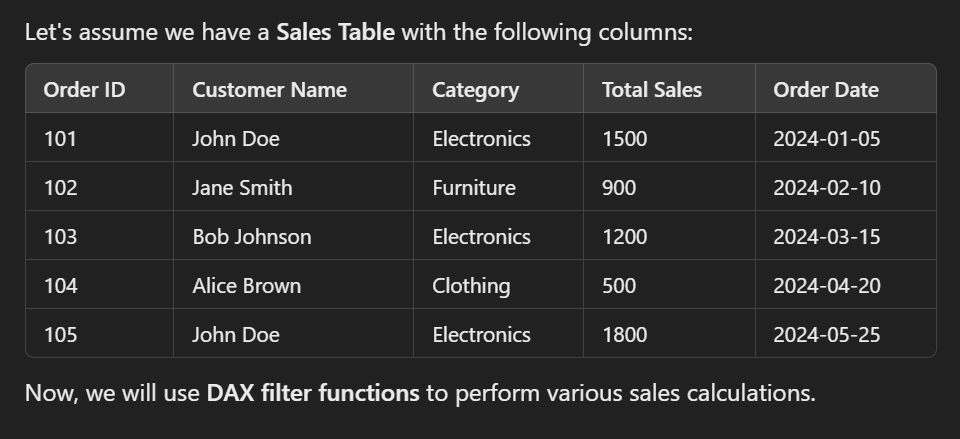

**1. We want to find the total sales where the amount is greater than 1000**

In [ ]:
High Sales Total = 
CALCULATE(
    SUM(Sales[Total Sales]), 
    FILTER(Sales, Sales[Total Sales] > 1000)
)

# Removes all filters from the Sales table (date, category, customer, etc.).
# Calculates the grand total of sales from all rows, regardless of any filters applied in slicers or visuals.

In [ ]:
TotalSalesOver1000 =
CALCULATE(
    SUM(Sales[Total Sales]),
    Sales[Total Sales] > 1000
)

# Filters the table to include only rows where Total Sales > 1000.
# Respects all other filters (like Category, Date, etc.) already applied in the report.

**2. We want to calculate total sales ignoring all filters applied in reports**

In [ ]:
Total Sales (Ignore Filters) = 
CALCULATE(
    SUM(Sales[Total Sales]), 
    ALL(Sales) # Removes any filters applied in visuals or slicers.
)


**3. If users select a specific date range or category in a visual, we want to show total sales based only on that selection**

In [ ]:
TotalSalesSelected = 
CALCULATE(
    SUM(Sales[Total Sales]), 
    ALLSELECTED(Sales) # Keeps only filters applied inside the visual.
)# If a user selects only Electronics category, this formula ensures the total is based only on that selection.

# Calculates total sales based on user selections from slicers and filters, but ignores filters applied inside the visual (like row-level context in a table).

In [ ]:
TotalSales =
SUM(Sales[Total Sales])

# Simple sum of Total Sales.
# Fully respects all filters currently applied (slicers, page filters, visual filters, etc.).


# 🔍 Why this works:
    # Power BI visuals automatically apply the current filter context (e.g., slicers or visual filters).
    # So, using SUM(Sales[Total Sales]) will respect all user selections, such as:
        # - Date range
        # - Category
        # - Customer Name
        # - Any other filters in the report
    
    # This is the standard way to show dynamic totals that respond to user interactions.

**When to use `ALLSELECTED`:**
Use this when you want a measure that shows a total relative to user selections, especially for things like:

- Showing a percentage of total (e.g., Sales / TotalSalesSelected)
- Showing grand totals relative to slicers

**4. We want to show total sales without category filtering, even if users apply a category filter**

In [ ]:
Total Sales (No Category Filter) = 
CALCULATE(
    SUM(Sales[Total Sales]), 
    REMOVEFILTERS(Sales[Category]) # Ensures that category filters do not affect the calculation.
)

# If a user selects only "Furniture," this formula ignores the selection and shows the full total.

**5. We want to keep existing filters while adding a new one (e.g., showing sales for Electronics only, while keeping date filters)**

In [ ]:
ElectronicsSalesKeepFilters = 
CALCULATE(
    SUM(Sales[Total Sales]), 
    KEEPFILTERS(Sales[Category] = "Electronics") # Keeps any existing filters (e.g., date filter) while ensuring only Electronics sales are included.
)# If a user filters the report to January, this formula ensures that it keeps the January filter and applies Electronics filter on top.

# This adds the "Electronics" filter on top of any existing filters rather than replacing them.
# If other filters already narrow down the category (e.g., user selected "Furniture"), this measure will return blank, because "Electronics" AND "Furniture" can't both be true — the filter context becomes stricter.

In [ ]:
ElectronicsSales =
CALCULATE( # CALCULATE keeps all the existing filters in context, such as Date, Customer Name, etc.
    SUM(Sales[Total Sales]),
    Sales[Category] = "Electronics"
)

# This replaces any existing filter on the Category column with "Electronics".
# If there’s already a slicer or filter on Category (e.g., user selected "Furniture"), this measure ignores it and shows only "Electronics" sales.
# Works well for forcing a single value regardless of slicers.

**💡 Tip:**

Use `KEEPFILTERS` when:

- You want to respect slicers but apply an additional constraint.- 
- You're working with complex filters or row-level security.

Use without `KEEPFILTERS` when:
- You want to force a specific category/value, no matter what the user selects.

In many real-world Power BI reports, we need to calculate the percentage of total sales based on applied filters. We'll use DAX filter functions to ensure our percentage calculations remain dynamic.

**We will calculate the percentage of total sales per category**

In [ ]:
# 1️⃣ Calculate Total Sales (Dynamic)
# First, we calculate the total sales respecting applied filters.

Total Sales = SUM(Sales[Total Sales])

# 2️⃣ Calculate Grand Total (Ignoring Filters)
# To get the total sales across all categories (ignoring filters), we use ALL().

Grand Total Sales = 
CALCULATE(
    SUM(Sales[Total Sales]), 
    ALL(Sales) # Removes any filters applied (like category selection in visuals).
)

# 3️⃣ Calculate Sales Percentage per Category
# Now, we calculate the percentage contribution of each category to total sales.

Sales % = 
DIVIDE( # DIVIDE(numerator, denominator, alternate_result)
    [Total Sales], 
    [Grand Total Sales], 
    0
)


# Calculate Sales % Within Selected Filters
# If the user selects a date range or category in a visual slicer, we use ALLSELECTED() to ensure the percentage calculation is based only on the selected data.
Sales % (Selected) = 
DIVIDE(
    [Total Sales], 
    CALCULATE(
        SUM(Sales[Total Sales]), 
        ALLSELECTED(Sales) # Keeps only filters applied by the user in the report.
    ), 
    0
)


## Time Intelligence Functions

Time Intelligence functions allow us to analyze data over different time periods (Year-to-Date, Quarter-to-Date, Month-to-Date, and Previous Periods). These functions are widely used in financial reports, trend analysis, and cumulative calculations.

**Sample Table:** Sales

| OrderDate  | SalesAmount               |
| ---------- | ------------------------- |
| 2023-01-10 | 120                       |
| 2023-01-11 | 200                       |
| 2023-01-12 | 180                       |
| 2023-02-03 | 150                       |
| 2023-02-15 | 210                       |
| 2023-02-20 | 175                       |
| 2024-01-05 | 220                       |
| 2024-01-10 | 190                       |
| 2024-01-14 | 230                       |
| 2024-02-18 | 205                       |
| 2024-02-22 | 250 ← **Current Context** |
| 2024-02-26 | 270                       |


**Assume you have a `Sales` table and a `Date` table connected via `Date[OrderDate]`.**

### DATESYTD
Returns all dates from the start of the year to the selected date.
    
**Syntax:** `DATESYTD(dates_column, [year_end_date])`

In [ ]:
SalesYTD =
CALCULATE(
    SUM(Sales[SalesAmount]),
    DATESYTD('Date'[OrderDate]) # return all dates from Jan 1, 2024 up to Feb 22, 2024(current context date)
)

# Output:
220 + 190 + 230 + 205 + 250 = 1,095

**🔍 Explanation:**
- DATESYTD(Sales[Order Date]) generates a date range from the start of the year (2025-01-01) up to the current date in context (e.g., 2025-04-05).

- CALCULATE() then filters the sales table to include only those dates and sums Sales[Total Sales] over them.

- This gives you the Year-To-Date sales total.

### DATESQTD
Returns all dates from the start of the quarter to the selected date.

**Syntax:** `DATESQTD(<dates_column>)`



In [ ]:
SalesQTD =
CALCULATE(
    SUM(Sales[SalesAmount]),
    DATESQTD('Date'[OrderDate]) # return all dates from Jan 1, 2024 up to Feb 22, 2024 (Q1 context)
)

# Output:
1,095

### DATESMTD
Returns all dates from the start of the month to the selected date.

**Syntax:** `DATESMTD(<dates_column>)`



In [ ]:
SalesMTD =
CALCULATE(
    SUM(Sales[SalesAmount]),
    DATESMTD('Date'[OrderDate]) # return all dates from Feb 1, 2024 up to Feb 22, 2024(current context date)
)

# Output:
205 + 250 = 455

**🔍 Summary:**
- DATESYTD() = From Jan 1 to current date

- DATESQTD() = From start of current quarter to current date

- DATESMTD() = From start of current month to current date

### PREVIOUSYEAR & NEXTYEAR
- `PREVIOUSYEAR` Returns a table containing a column of dates for the entire previous year.
- `NEXTYEAR` Returns a table that contains all the dates in the next year.

**Syntax:** 
- `PREVIOUSYEAR(dates_column, [year_end_date])`
- `NEXTYEAR(dates_column, [year_end_date])`


In [ ]:
PreviousYearSales =
CALCULATE(
    SUM(Sales[SalesAmount]),
    PREVIOUSYEAR('Date'[OrderDate]) # return dates: 2023-01-10, 2023-01-11, 2023-01-12, 2023-02-03, 2023-02-15, 2023-02-20
)

# Output:
120 + 200 + 180 + 150 + 210 + 175 = 1,035

In [ ]:
NextYearSales =
CALCULATE(
    SUM(Sales[SalesAmount]),
    NEXTYEAR('Date'[OrderDate]) # return all dates of 2025, which is not present
)

# Output:
0

### PREVIOUSMONTH & NEXTMONTH
- `PREVIOUSMONTH` returns a table that contains a column of dates for the entire previous month.
- `NEXTMONTH` returns a table that contains all the dates in the next month.
    
**Syntax:** 
- `PREVIOUSMONTH(dates_column)`
- `NEXTMONTH(dates_column)`


In [ ]:
PreviousMonthSales =
CALCULATE(
    SUM(Sales[SalesAmount]),
    PREVIOUSMONTH('Date'[OrderDate]) # return dates: 2024-01-05, 2024-01-10, 2024-01-14 
)

# Output:
220 + 190 + 230 = 640

In [ ]:
NextMonthSales =
CALCULATE(
    SUM(Sales[SalesAmount]),
    NEXTMONTH('Date'[OrderDate]) # return all dates of March 2024, which is not present in table
)

# Output:
0

### PREVIOUSDAY & NEXTDAY
- `PREVIOUSDAY` Returns a table that contains a column of the date that is the previous day from the current context date.
- `NEXTDAY` eturns a table that contains a column of the date that is the next day.

**Syntax:** 
- `PREVIOUSDAY(dates_column)`
- `NEXTDAY(dates_column)`


In [ ]:
PreviousDaySales =
CALCULATE(
    SUM(Sales[SalesAmount]),
    PREVIOUSDAY('Date'[OrderDate]) # return 2024-02-21, which is not present in table
)

# Output:
0

In [ ]:
NextDaySales =
CALCULATE(
    SUM(Sales[SalesAmount]),
    NEXTDAY('Date'[OrderDate]) # return 2024-02-23, which is not present in table
)

# Output:
0

## Ranking & Statistical Functions
These functions help in ranking, calculating percentiles, and finding the median in datasets. They are useful in scenarios like leaderboards, percentile analysis, and statistical insights in Power BI.

### RANKX
Ranks values based on a measure

**Syntax:** `RANKX(table, expression, [value], [order], [ties])`

- table: The table or dataset to rank values within.
- expression: The measure or column used for ranking (e.g., SUM(Sales[Total Sales])).
- [value]: (Optional) The specific value to rank (usually ignored).
- [order]: DESC for highest value first (default), ASC for lowest value first.
- [ties]: Dense (ranks consecutively) or Skip (skips ranks for ties).

In [ ]:
# Sales[Product Name], Sales[Total Sales]:  
"Phone"   → 1000  
"Laptop"  → 1500  
"Tablet"  → 1000  
"Monitor" → 800  

Product Rank = 
RANKX(
    ALL(Sales[Product Name]),   #-- Table to rank within
    SUM(Sales[Total Sales]),    #-- Measure to rank
    ,                           #-- Skip optional value
    DESC,                       #-- Rank from highest to lowest
    DENSE                       #-- Consecutive ranking (no gaps)
)

# Output:
Laptop   → 1  
Phone    → 2  
Tablet   → 2  
Monitor  → 3


# The highest-selling product gets rank 1.
# If two products have the same sales, they get the same rank (dense ranking).


### PERCENTILE.INC
Finds percentile including min/max

**Syntax:** `PERCENTILE.INC(column, percentile)`

- column: The column with numeric values.
- percentile: A value between 0 and 1 representing the desired percentile.

In [ ]:
# Sales[Total Sales]:  
100, 200, 300, 400, 500, 600, 700, 800, 900, 1000  

90th Percentile Sales = 
PERCENTILE.INC(Sales[Total Sales], 0.90)

# Output: 910


# This finds the sales value at or above which 10% of the data points fall.

### PERCENTILE.EXC
Finds percentile excluding min/max

**Syntax:** `PERCENTILE.EXC(column, percentile)`


In [ ]:
# Sales[Total Sales]:  
100, 200, 300, 400, 500, 600, 700, 800, 900, 1000  

25th Percentile Sales = 
PERCENTILE.EXC(Sales[Total Sales], 0.25)

# Output: 325


- PERCENTILE.INC() includes all values.
- PERCENTILE.EXC() ignores min/max values, giving slightly different results.

### MEDIAN
Finds the middle value of a column

**Syntax:** `MEDIAN(column)`



In [ ]:
# Sales[Total Sales]:  
100, 200, 300, 400, 500, 600, 700

Median Sales = MEDIAN(Sales[Total Sales])

# Output: 400


## Relationships & Lookup Functions
These functions fetch related data from other tables based on established relationships. They are useful for data modeling, lookup operations, and table navigation in Power BI.

### RELATED
The RELATED function in DAX is used to bring a value from a related table into the current table, based on a relationship that already exists in your data model.

👉 Think of it like a VLOOKUP in Excel, where you pull data from another table using a common key.

**Syntax:** `RELATED(<ColumnName>)`

- ColumnName: The column you want to bring into the current table (from a related table).

**🔹 How it works:**
You can only use `RELATED` in the “many” side of a relationship to pull values from the “one” side.

📌 Example: If you have a relationship like `Orders (many) → Customers (one)`, you can use RELATED in the Orders table to get fields from Customers.

**🧠 When to Use `RELATED`**
- When you want to enrich your data model by bringing in columns from related tables.
- Especially useful in calculated columns in the “many” table.
    
You usually do NOT need RELATED in measures, because DAX measures automatically "see" the related tables due to filter context. But in very specific cases, you can use it — especially if you're building a calculated measure that depends on values from a lookup table.

<hr>

Example: We have two tables:
- 🔹 Sales table with Order ID, Product ID, Sales Amount.
- 🔹 Products table with Product ID, Product Name, Category.

In [ ]:
# Retrieve the Product Name in the Sales table:

# Sales table (Many side):  
Order ID | Product ID | Sales Amount  
------------------------------------  
001      | P01        | 500  
002      | P02        | 300  
003      | P03        | 400  

# Products table (One side):  
Product ID | Product Name   | Category  
--------------------------------------  
P01        | Laptop         | Electronics  
P02        | Headphones     | Electronics  
P03        | Chair          | Furniture  

# Formula (in Sales table):
Product Name = RELATED(Products[Product Name])

# Output in Sales table:  
Order ID | Product ID | Sales Amount | Product Name  
---------------------------------------------------  
001      | P01        | 500          | Laptop  
002      | P02        | 300          | Headphones  
003      | P03        | 400          | Chair  


# Power BI looks up Product Name from the Products table.
# Works only if a relationship exists between Sales[Product ID] and Products[Product ID].

**Explanation:**
- RELATED() fetches a column value from a related table (one side of a relationship).
- Requires a relationship between Sales[Product ID] and Products[Product ID].
- Best used in calculated columns, not measures.

#### Using RELATED in Power BI Visuals

Suppose you’re working with the `Order Table(Many side):OrderID, CustomerID, OrderAmount` and `Customers Table (One side):CustomerID, CustomerName, Country`

And you want to create a Table visual in Power BI that shows: `Order ID`, `Customer Name`, `Order Amount`

Since `Customer Name` is in a different table, you can:

**➤ Step 1: Create a calculated column in Orders**

Go to Orders table → New Column:`CustomerName = RELATED(Customers[CustomerName])`

Now, in your Power BI Table visual, drag: `OrderID`, `CustomerName` (the new column), `OrderAmount`

### RELATEDTABLE

The RELATEDTABLE function is the opposite of RELATED.

- 🔁 While RELATED pulls a single value from a related table (one side) into the current table (many side),
- ✅ RELATEDTABLE returns a table of rows from a related table (many side) that are connected to the current row (one side).

**📘 In short:** "RELATEDTABLE gives you all the rows from another table that are connected to the current row you're working with."

**Syntax:** `RELATEDTABLE(<TableName>)`

- TableName: The table that contains related rows.

📌 Example: Suppose you’re working with the `Order Table(Many side):OrderID, CustomerID, OrderAmount` and `Customers Table (One side):CustomerID, CustomerName`.

Let’s say you want to calculate total sales per customer, inside the Customers table. You can create a calculated column in the Customers table: `TotalSales = SUMX(RELATEDTABLE(Orders), Orders[OrderAmount])`

What this does:

- For each customer in the Customers table,
- RELATEDTABLE(Orders) pulls all the matching rows from Orders,
- SUMX then adds up the OrderAmount for those orders.


**🧠 When to Use RELATEDTABLE**
    
Use it when:

- You're on the “one” side of a one-to-many relationship.
- You want to access the related rows from the “many” side.
- You're building aggregations, filters, or row context from related tables.

`RELATEDTBALE` Returns a table (not a single value), which you can use in functions like `COUNTROWS`, `SUMX`, `AVERAGEX`, etc.

In [ ]:
# Products table(One side):  
Product ID | Product Name   | Category  
--------------------------------------  
P01        | Laptop         | Electronics  
P02        | Headphones     | Electronics  
P03        | Chair          | Furniture  

# Sales table(Many side):  
Order ID | Product ID | Sales Amount  
------------------------------------  
001      | P01        | 500  
002      | P01        | 600  
003      | P02        | 300  
004      | P03        | 400  

# Formula (in Products table):
Total Sales = SUMX(RELATEDTABLE(Sales), Sales[Sales Amount])
# For each row in the Products table, get all related rows from the Sales table.


# Output in Products table:  
Product ID | Product Name | Category     | Total Sales  
--------------------------------------------------------  
P01        | Laptop       | Electronics  | 1100   (500 + 600)  
P02        | Headphones   | Electronics  | 300  
P03        | Chair        | Furniture    | 400  


**How it is working?**

`➤ Row 1: Product ID = P01 (Laptop)`
    RELATEDTABLE(Sales) → all rows in Sales where Product ID = P01

    - Order 001: 500
    - Order 002: 600
    - SUMX(...) → 500 + 600 = 1100
    - 👉 Total Sales = 1100

`➤ Row 2: Product ID = P02 (Headphones)`
    RELATEDTABLE(Sales) → rows where Product ID = P02

    - Order 003: 300
    - SUMX(...) → 300
    - 👉 Total Sales = 300

`➤ Row 3: Product ID = P03 (Chair)`
    RELATEDTABLE(Sales) → rows where Product ID = P03

    - Order 004: 400
    - SUMX(...) → 400
    - 👉 Total Sales = 400

Example: We have two tables:
- 🔹 Customers table (Customer ID, Customer Name).
- 🔹 Orders table (Order ID, Customer ID, Order Amount).

In [ ]:
# Retrieve orders for a customer:

# Customers table:  
Customer ID | Customer Name  
----------------------------  
C01         | Alice  
C02         | Bob  
C03         | Carol  

# Orders table:  
Order ID | Customer ID | Order Amount  
-------------------------------------  
001      | C01         | 100  
002      | C01         | 150  
003      | C02         | 200  
004      | C01         | 250  
005      | C03         | 300  

# Formula (in Customers table):
Customer Orders = COUNTROWS(RELATEDTABLE(Orders))

# Output in Customers table:  
Customer ID | Customer Name | Customer Orders  
---------------------------------------------  
C01         | Alice         | 3    (Orders: 001, 002, 004)  
C02         | Bob           | 1    (Order: 003)  
C03         | Carol         | 1    (Order: 005)   


# For each customer in the Customers table, it counts related orders from Orders.
# Works from parent (Customers) to child (Orders).

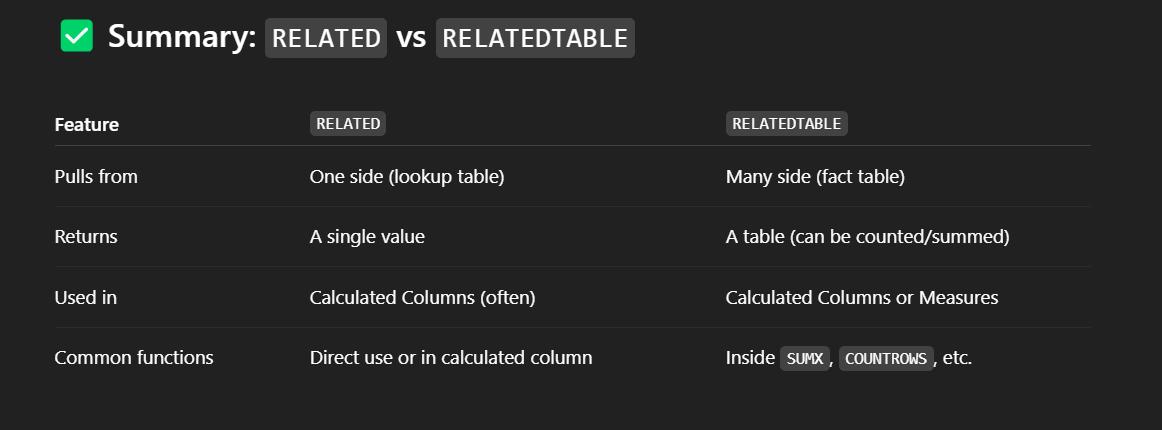

**Tips:** Use `RELATED` in the many-side (Orders) and `RELATEDTABLE` in the one-side (Customers)

### LOOKUPVALUE
LOOKUPVALUE is used to look up a value in another table, kind of like VLOOKUP in Excel, but with more control and flexibility.

It returns a single value from a table, based on one or more matching conditions.

**Syntax:** `LOOKUPVALUE(<ResultColumn>, <SearchColumn>, <SearchValue>, [<SearchColumn2>, <SearchValue2>], ...)`

- ResultColumn: The column from which the value will be returned.
- SearchColumn: The column where the function looks for the search value.
- SearchValue: The value to find in the search column.
- SearchColumn2, SearchValue2: (Optional) Additional conditions to match.

📌 Example: Suppose you have two tables: `Employees Table (Main Table): EmployeeID, Name` and `Salaries Table (Lookup Table): EmployeeID, Salary`.

You want to bring the salary into the Employees table. So, in the Employees table, create a new calculated column: `Salary = LOOKUPVALUE(Salaries[Salary], Salaries[EmployeeID], Employees[EmployeeID])`.

This means: Look in the `Salaries` table, return the value from the `Salary` column where `EmployeeID` matches the current row's `EmployeeID`.

**🔸 When to Use LOOKUPVALUE**
- When there's no relationship between two tables
- Or you want to do a quick lookup without building a relationship
- When using multiple conditions to get a value

In [ ]:
# Find Product Category Based on Product ID

# Sales table:  
Order ID | Product ID | Sales Amount  
------------------------------------  
001      | P01        | 500  
002      | P02        | 300  
003      | P01        | 400  

# Products table:  
Product ID | Product Name   | Category  
--------------------------------------  
P01        | Laptop         | Electronics  
P02        | Headphones     | Electronics  
P03        | Chair          | Furniture  

# Formula (in Sales table):
Product Category = LOOKUPVALUE(Products[Category], Products[Product ID], Sales[Product ID])

# Output in Sales table:  
Order ID | Product ID | Sales Amount | Product Category  
-----------------------------------------------------  
001      | P01        | 500          | Electronics  
002      | P02        | 300          | Electronics  
003      | P01        | 400          | Electronics  


# Finds the Category in Products where Product ID in Products matches Sales[Product ID].
# Works like a VLOOKUP in Excel.

In [ ]:
# Find Employee Salary Based on Multiple Conditions

# Employees table:  
Employee Name | Department | Salary  
------------------------------------  
John Doe     | Finance    | 50000  
Jane Smith   | HR         | 45000  
John Doe     | Marketing  | 55000  

# Formula (in another table, e.g., Payroll or any other context):
Employee Salary = LOOKUPVALUE(
    Employees[Salary], 
    Employees[Employee Name], "John Doe", 
    Employees[Department], "Finance"
)

# Output:  
Employee Salary = 50000


# Finds Salary where Employee Name = "John Doe" and Department = "Finance".

- ✔ RELATED: Fetches a single value when a relationship exists.
- ✔ RELATEDTABLE: Retrieves a filtered table when a relationship exists.
- ✔ LOOKUPVALUE: Finds a specific value without needing a relationship.

## CALCULATE & Context Modification

### CALCULATE
The CALCULATE() function modifies the filter context of a measure or calculation. It evaluates an expression under the modified filter conditions.

**Syntax:** `CALCULATE(expression, filter1, filter2, ...)`

- expression → The calculation to perform.
- filter1, filter2, ... → Optional filters applied to modify context.

In [ ]:
# Find total sales only for the "Electronics" category.

# Sales table:  
Order ID | Product ID | Sales Amount  
------------------------------------  
001      | P01        | 500  
002      | P02        | 300  
003      | P03        | 400  

# Products table:  
Product ID | Product Name   | Category  
--------------------------------------  
P01        | Laptop         | Electronics  
P02        | Headphones     | Electronics  
P03        | Chair          | Furniture  

# Formula (measure):
Electronics Sales = 
CALCULATE(
    SUM(Sales[Sales Amount]), 
    Products[Category] = "Electronics"
)

# Output:  
Electronics Sales = 800

# This requires an active relationship between Sales[Product ID] and Products[Product ID]

### CALCULATETABLE
The CALCULATETABLE() function returns a modified table based on applied filters.

**Syntax:** `CALCULATETABLE(table, filter1, filter2, ...)`

- table → The table to modify.
- filter1, filter2, ... → Filters applied to modify context.

In [ ]:
# Return a table containing only orders from Electronics.

# Sales table:  
Order ID | Product ID | Sales Amount  
------------------------------------  
001      | P01        | 500  
002      | P02        | 300  
003      | P03        | 400  

# Products table:  
Product ID | Product Name   | Category  
--------------------------------------  
P01        | Laptop         | Electronics  
P02        | Headphones     | Electronics  
P03        | Chair          | Furniture  

# Formula (calculated table):
Electronics Sales Table = 
CALCULATETABLE(
    Sales, 
    Products[Category] = "Electronics"
)

# Output (resulting table):  
Order ID | Product ID | Sales Amount  
------------------------------------  
001      | P01        | 500  
002      | P02        | 300  


### USERELATIONSHIP
By default, Power BI only uses one active relationship between tables.
If there is a second inactive relationship, USERELATIONSHIP() can be used to activate it for a specific calculation.

**Syntax:** `USERELATIONSHIP(column1, column2)`

- column1, column2 → The columns forming the inactive relationship.

Example:

We have `Sales` and `Calendar` table and a retail company wants to analyze sales based on two different dates:

1. Order Date (when the customer placed the order)
2. Ship Date (when the product was actually shipped)

**📌 Problem:**
- The Sales table contains both Order Date and Ship Date, but only one active relationship can exist with the Calendar table at a time.
- By default, Power BI uses the active relationship, which is Sales[Order Date] → Calendar[Date].
- However, to analyze sales based on the Ship Date, we need to use the inactive relationship.

In [ ]:
Total Sales = SUM(Sales[Sales Amount]) # This works based on the active relationship (Order Date)

Sales by Ship Date = 
CALCULATE(
    SUM(Sales[Sales Amount]), 
    USERELATIONSHIP(Sales[Ship Date], Calendar[Date])
)
# This measure forces Power BI to use the inactive Ship Date relationship.

### CROSSFILTER 
CROSSFILTER() changes the direction of the relationship between two tables.

**Syntax:** `CROSSFILTER(column1, column2, direction)`

- column1, column2 → The columns forming the relationship.
- direction: One of these:
    - "None" – disables the relationship
    - "OneWay" – filters only from first to second column
    - "Both" – enables bidirectional filtering

Example:

A company has a `Sales` Table and a `Customers` Table, linked by `Customer ID`.
By default, relationships in Power BI are single-directional (from Customers → Sales).
However, in some cases, we need a bidirectional relationship to analyze data dynamically.

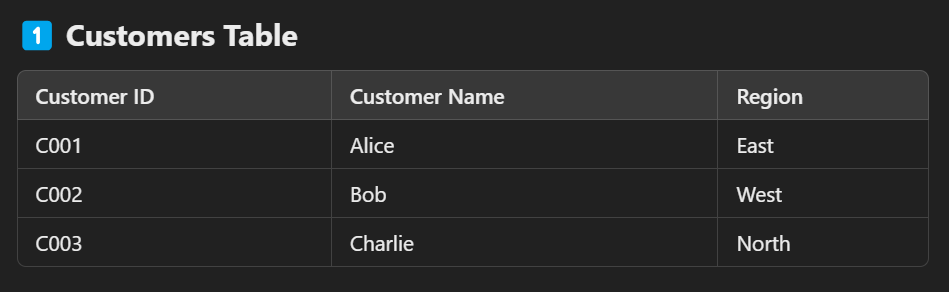

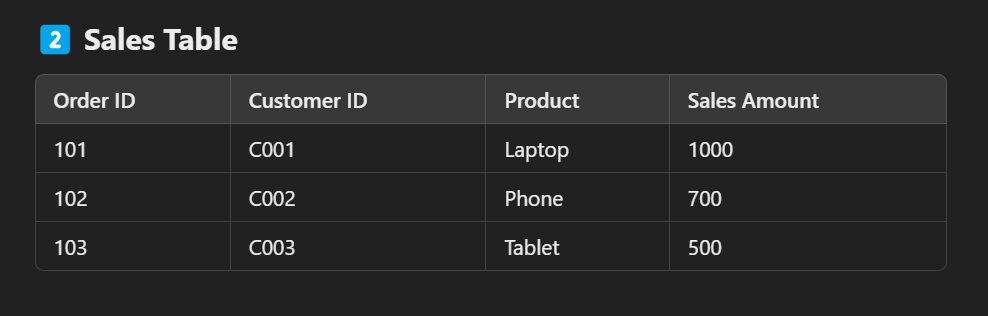

- The Customers Table (One) → Sales Table (Many) relationship is single-directional.
- This means we can filter Sales by Customers, but we cannot filter Customers by Sales.

**💡 Problem:**
If we create a report showing regions with no sales, the default setup won’t work because Power BI doesn’t filter Customers based on Sales.

To analyze sales while also filtering customers dynamically, we use CROSSFILTER.

In [ ]:
Total Sales (Bidirectional) = 
CALCULATE(
    SUM(Sales[Sales Amount]), 
    CROSSFILTER(Customers[Customer ID], Sales[Customer ID], BOTH)
)
# This forces bidirectional filtering, allowing customers to be filtered based on sales.



## Iterators (Row-by-Row Operations)
Iterator functions (X functions) work row by row in a table, performing calculations on each row and then aggregating the results.

### SUMX
Returns the sum of an expression evaluated row by row over a table.

**Syntax:** `SUMX(table, expression)`

- table → The table in which the expression will be evaluated.
- expression → The calculation performed for each row.

In [ ]:
Total Revenue = SUMX(Sales, Sales[Quantity] * Sales[Price])

# Multiplies Quantity and Price for each row.
# Then sums up the total for all rows.

### AVERAGEX
- Calculates the average of an expression evaluated row by row.
- Works like SUMX, but returns an average instead of a sum.

**Syntax:** `AVERAGEX(table, expression)`



In [ ]:
Avg Order Value = AVERAGEX(Sales, Sales[Quantity] * Sales[Price])

# Calculates Revenue for each order.
# Averages the Revenue across all orders.

### MINX
- Finds the minimum value of an expression evaluated row by row.
- Evaluates each row, returns the smallest value.

**Syntax:** `MINX(table, expression)`

In [ ]:
Min Order Revenue = MINX(Sales, Sales[Quantity] * Sales[Price])

### MAXX
- Finds the maximum value of an expression evaluated row by row.
- Evaluates each row, returns the largest value.

**Syntax:** `MAXX(table, expression)`



In [ ]:
Max Order Revenue = MAXX(Sales, Sales[Quantity] * Sales[Price])

### COUNTX
- Counts the number of rows where an expression evaluates to a non-blank value.
- Counts rows where expression is not blank.- 

**Syntax:** `COUNTX(table, expression)`



In [ ]:
Count High Sales = COUNTX(Sales, IF(Sales[Quantity] * Sales[Price] > 1000, 1, BLANK()))

### Examples:

In [ ]:
# Sales Table:

| Product | Quantity | Price | Discount |
| ------- | -------- | ----- | -------- |
| A       | 2        | 50    | 5        |
| B       | 1        | 100   | 10       |
| C       | 3        | 30    | 0        |
| D       | 4        | 20    | 2        |


SUMX(Sales, Sales[Quantity] * Sales[Price]) # 370

AVERAGEX(Sales, Sales[Quantity] * Sales[Price]) # 92.5

MINX(Sales, Sales[Quantity] * Sales[Price]) # 80 (Row values = 100, 100, 90, 80)

MAXX(Sales, Sales[Quantity] * Sales[Price]) # 100

COUNTX(Sales, Sales[Quantity] * Sales[Price]) # 4 (Row expressions = 100, 100, 90, 80 → all non-blank)

## Advanced Time Intelligence Functions
These Time Intelligence functions help analyze date-based data, such as comparisons between different time periods.

### DATESBETWEEN
The DATESBETWEEN function returns a table of dates from a date column, filtered between a start date and an end date (inclusive).


**Syntax:** `DATESBETWEEN(dates_column, start_date, end_date)`

- dates_column → A column containing dates.
- start_date → The start of the range.
- end_date → The end of the range.

In [ ]:
Sales Last 30 Days = 
CALCULATE(
    SUM(Sales[Total Sales]), 
    DATESBETWEEN(Sales[Order Date], TODAY() - 30, TODAY())
)


**📌 Use Case:** A sales manager wants to track total revenue between two specific dates, e.g., sales from Jan 1, 2024, to Jan 31, 2024.

In [ ]:
Sales in January 2024 = 
CALCULATE(
    SUM(Sales[Total Sales]), 
    DATESBETWEEN(Sales[Order Date], DATE(2024,1,1), DATE(2024,1,31))
)


### PARALLELPERIOD
The PARALLELPERIOD function returns a column of dates that represents a parallel period (e.g., the same period from the previous year, month, or quarter) based on a given date column.


**Syntax:** `PARALLELPERIOD(dates_column, number_of_intervals, interval)`

- dates_column → A column containing dates.
- number_of_intervals → How many periods to shift (+/- values).
- interval → DAY, MONTH, QUARTER, YEAR.

Assume you have a `Sales` table and a `Date` table connected via `Date[Date]`. You want to calculate sales for the same month last year.

**Current date context:** 2024-04-01

| Date       | Total Sales |
| ---------- | ----------- |
| 2023-01-01 | 100         |
| 2023-02-01 | 120         |
| 2023-03-01 | 150         |
| 2023-04-01 | 130         |
| 2023-05-01 | 140         |
| 2024-01-01 | 180         |
| 2024-02-01 | 200         |
| 2024-03-01 | 210         |
| 2024-04-01 | 190         |


In [ ]:
Sales Last Year = 
CALCULATE(
    SUM(Sales[Total Sales]), 
    PARALLELPERIOD(Date[OrderDate], -1, Year) # will shift it to 2023-04-01.
)
               
# Output:
130

In [ ]:
Sales Previous Quarter = 
CALCULATE(
    SUM(Sales[SalesAmount]),
    PARALLELPERIOD(Date[OrderDate], -1, QUARTER) # return Q1 of 2024 (Jan–Mar 2024).
)

# Output:
180 + 200 + 210 = 590


In [ ]:
Sales Previous Month = 
CALCULATE(
    SUM(Sales[SalesAmount]),
    PARALLELPERIOD(Date[OrderDate], -1, MONTH) # Shifts the date context back 1 month.
)

# Output:
210

In [ ]:
Sales Previous Day = 
CALCULATE(
    SUM(Sales[SalesAmount]),
    PARALLELPERIOD(Date[OrderDate], -1, DAY) # Shifts the current date context back by 1 day.
)

# Output:
0

The PARALLELPERIOD function shifts the date context back by 1 year. If, for example, the current context is January 2024, PARALLELPERIOD would shift the context to January 2023.

In DAX, the current context refers to the specific slice of data that you're working with, based on filters, rows, columns, and visual selections in Power BI. It can be influenced by:

- Slicers: Any slicers applied on the report or visual.
- Rows and Columns: The fields in the rows, columns, or axis of a visual (for example, if you have OrderDate or Month in a table).
- Filters: Any other filters that might be applied at the report, page, or visual level.

The "current context" is essentially the set of data that Power BI uses to calculate the measure. When a DAX formula is evaluated, Power BI evaluates it in the context of the currently selected row or column, the filter on the visual, or the date range applied.


**📌 Use Case:** A CEO wants to compare current quarter’s sales with the previous quarter.

In [ ]:
Sales Last Quarter = 
CALCULATE(
    SUM(Sales[Total Sales]), 
    PARALLELPERIOD(Date[OrderDate], -1, QUARTER)
)


### SAMEPERIODLASTYEAR
SAMEPERIODLASTYEAR() returns a table of dates that represent the same period from the previous year as the current context.


**Syntax:** `SAMEPERIODLASTYEAR(dates_column)`

- dates_column → A column containing dates.

In [ ]:
| OrderDate  | SalesAmount |
| ---------- | ----------- |
| 2023-01-05 | 120         |
| 2023-02-10 | 200         |
| 2023-03-15 | 150         |
| 2024-01-10 | 180         |
| 2024-02-05 | 220         |

SalesLastYear = 
CALCULATE(
    SUM(Sales[SalesAmount]),
    SAMEPERIODLASTYEAR('Date'[Date])
)

# Output:
120 + 200 = 320

- For January 2024 (current context), SAMEPERIODLASTYEAR will look at January 2023.
- For February 2024 (current context), SAMEPERIODLASTYEAR will look at February 2023.
- For Q1 2024, it returns Q1 2023.

**📌 Use Case:** A retail store wants to compare this month’s sales with the same month last year.

In [ ]:
Sales Same Month Last Year = 
CALCULATE(
    SUM(Sales[Total Sales]), 
    SAMEPERIODLASTYEAR(Sales[Order Date])
)


##  Variables & Performance Optimization
Using VAR (Variables) in DAX improves readability, reusability, and performance by avoiding redundant calculations.



### VAR Syntax


`VAR variable_name = expression`

`RETURN result_expression`

- VAR: Defines a variable.
- RETURN: Returns the final result after computation.


### Why Use Variables in DAX?
- ✅ Performance Optimization: Prevents recalculating the same value multiple times.
- ✅ Readability & Maintainability: Makes complex formulas easier to understand.
- ✅ Reusability: Stores intermediate results for later use.

### Example 1: Using VAR to Improve Performance
📌 Scenario: Calculate Profit Margin for each product where:

`Profit Margin (%) = (Total Profit / Total Sales) * 100`

**Without VAR (Redundant Calculation):**

In [ ]:
Profit Margin = 
(SUM(Sales[Total Profit]) / SUM(Sales[Total Sales])) * 100

# 🚨 Issue: SUM(Sales[Total Profit]) and SUM(Sales[Total Sales]) are calculated twice, reducing performance.

**With VAR (Optimized Calculation):**

In [ ]:
Profit Margin Optimized = 
VAR TotalProfit = SUM(Sales[Total Profit])
VAR TotalSales = SUM(Sales[Total Sales])
RETURN (TotalProfit / TotalSales) * 100

# TotalProfit and TotalSales are stored in variables, so they don't get recalculated multiple times.

1. Scope of Variables: In DAX, variables are defined and used within the measure where they are created. So, the variables TotalProfit and TotalSales you define in your Profit Margin Optimized measure can only be used within that measure or in calculations nested inside it.

2. Reusing Variables Across Measures: You cannot directly reuse variables from one measure in another measure because variables in DAX are local to the measure where they are declared. However, you can duplicate the logic or define a similar variable in another measure.

### Example 2: Conditional Calculation with VAR
📌 Scenario: Classify products based on profit margin:

- High Profit if Margin > 20%
- Medium Profit if 10% ≤ Margin ≤ 20%
- Low Profit if Margin < 10%

In [ ]:
Profit Category = 
VAR Margin = (SUM(Sales[Total Profit]) / SUM(Sales[Total Sales])) * 100
RETURN 
    IF(Margin > 20, "High Profit", 
       IF(Margin >= 10, "Medium Profit", "Low Profit"))

# Without VAR, the margin formula is recalculated inside each IF condition.
# With VAR, we calculate Margin once and reuse it.

### Example 3: Using VAR with CALCULATE
📌 Scenario: Get Sales for the Top 5 Customers.

In [ ]:
Top 5 Customers Sales = 
VAR TopCustomers = 
    TOPN(5, SUMMARIZE(Sales, Sales[Customer ID], "Total Sales", SUM(Sales[Total Sales])), [Total Sales], DESC)
RETURN 
    CALCULATE(SUM(Sales[Total Sales]), TopCustomers)

# The VAR stores the top 5 customers, avoiding redundant calculations inside CALCULATE.

### Example 4: Optimizing CALCULATE with VAR 
We need to calculate total sales for the current year and previous year and then compute the growth percentage.

In [ ]:
# 🔴 Without VAR (Inefficient Calculation)

Sales Growth = 
((CALCULATE(SUM(Sales[Total Sales]), YEAR(Sales[Order Date]) = YEAR(TODAY())) - 
  CALCULATE(SUM(Sales[Total Sales]), YEAR(Sales[Order Date]) = YEAR(TODAY()) - 1)) / 
  CALCULATE(SUM(Sales[Total Sales]), YEAR(Sales[Order Date]) = YEAR(TODAY()) - 1)) * 100

# CALCULATE(SUM(Sales[Total Sales])...) is repeated multiple times, slowing performance.

In [ ]:
# 🟢 With VAR (Optimized Calculation)

Sales Growth Optimized = 
VAR CurrentYearSales = CALCULATE(SUM(Sales[Total Sales]), YEAR(Sales[Order Date]) = YEAR(TODAY()))
VAR PreviousYearSales = CALCULATE(SUM(Sales[Total Sales]), YEAR(Sales[Order Date]) = YEAR(TODAY()) - 1)
RETURN 
    ((CurrentYearSales - PreviousYearSales) / PreviousYearSales) * 100

### Example 5: Conditional Discounts for High-Value Customers
📌 Problem:

- If total purchases by a customer exceed $10,000, apply a 10% discount.
- Otherwise, apply a 5% discount.


In [ ]:
# 🔴  Without VAR (Repetitive Calculation)

Discount Amount = 
IF(SUM(Sales[Total Sales]) > 10000, SUM(Sales[Total Sales]) * 0.1, SUM(Sales[Total Sales]) * 0.05)

# 🚨 Issue: SUM(Sales[Total Sales]) is calculated twice.

In [ ]:
# 🟢 With VAR (Optimized)

Discount Amount Optimized = 
VAR TotalSales = SUM(Sales[Total Sales])
VAR DiscountRate = IF(TotalSales > 10000, 0.1, 0.05)
RETURN TotalSales * DiscountRate

### Example 6: Finding the Best-Selling Product in Each Category
📌 Problem:
We need to find the best-selling product in each category based on total sales.

In [ ]:
# 🔴 Without VAR (Inefficient)

Best Selling Product = 
TOPN(1, 
     SUMMARIZE(Sales, Sales[Product Name], "Total Sales", SUM(Sales[Total Sales])), 
     [Total Sales], DESC)

# 🚨 Issue: The SUM(Sales[Total Sales]) is computed multiple times inside TOPN.

In [ ]:
# 🟢 With VAR (Optimized)

Best Selling Product Optimized = 
VAR ProductSales = SUMMARIZE(Sales, Sales[Product Name], "Total Sales", SUM(Sales[Total Sales]))
RETURN 
    TOPN(1, ProductSales, [Total Sales], DESC)

### Example 7: Performance Comparison – Using VAR in Measures

In [ ]:
# 🔴 Without VAR

Sales Performance = 
IF(SUM(Sales[Total Sales]) > 50000, "High Performer", "Average Performer")

# 🚨 Issue: SUM(Sales[Total Sales]) runs twice.

In [ ]:
# 🟢 With VAR

Sales Performance Optimized = 
VAR TotalSales = SUM(Sales[Total Sales])
RETURN IF(TotalSales > 50000, "High Performer", "Average Performer")

## Other functions

### SUMMARIZE
SUMMARIZE is one of the most powerful DAX functions used for grouping and summarizing data. It allows you to create a table with grouped columns and aggregated values.

**Syntax:** `SUMMARIZE(
    table,
    groupBy_column1,
    [groupBy_column2, ...],
    [name1, expression1],
    [name2, expression2], ...
)`

- table – The original table from which data will be summarized.
- groupBy_column – The column(s) used for grouping the data.
- name1 – The name of the new calculated column (must be in double quotes " ").
- expression1 – The DAX formula used for aggregation (e.g., SUM, COUNT, AVERAGE).

Example:

We have a Sales table with columns: Category, Product Name, Total Sales. We want to group by Category and calculate the Total Sales per Category.

In [ ]:
Category Sales Summary = 
SUMMARIZE(
    Sales, 
    Sales[Category],  
    "Total Sales", SUM(Sales[Total Sales])
)

In [ ]:
# Summarizing Sales by Category & Product

Category Product Sales Summary = 
SUMMARIZE(
    Sales, 
    Sales[Category], 
    Sales[Product Name],  
    "Total Sales", SUM(Sales[Total Sales])
)


In [ ]:
# Counting Customers per Region

Customer Count by Region = 
SUMMARIZE(
    Sales, 
    Sales[Region],  
    "Unique Customers", DISTINCTCOUNT(Sales[Customer ID])
)


- ✔ Use SUMMARIZE for grouping data efficiently
- ✔ Always use an aggregation function in calculated columns (e.g., SUM, COUNT, AVERAGE)
- ✔ If performance is slow, use SUMMARIZECOLUMNS instead (recommended for Power BI models)

### SUMMARIZECOLUMNS
SUMMARIZECOLUMNS is an optimized version of SUMMARIZE. It is used to create summary tables by grouping data and applying aggregations. Unlike SUMMARIZE, it does not require a base table and is more efficient when working with Power BI models.

**Syntax:** `SUMMARIZECOLUMNS(
    groupBy_column1, 
    [groupBy_column2, ...],
    [name1, expression1],
    [name2, expression2], ...
)`

- groupBy_column – The column(s) used for grouping the data.
- name1 – The name of the new calculated column (must be in double quotes " ").
- expression1 – The DAX formula used for aggregation (e.g., SUM, COUNT, AVERAGE).

In [ ]:
# Sales by Category

Category Sales Summary = 
SUMMARIZECOLUMNS(
    Sales[Category],  
    "Total Sales", SUM(Sales[Total Sales])
)


In [ ]:
# Sales by Category & Region

Category Region Sales Summary = 
SUMMARIZECOLUMNS(
    Sales[Category], 
    Sales[Region],  
    "Total Sales", SUM(Sales[Total Sales])
)


In [ ]:
# Unique Customers by Region

Customer Count by Region = 
SUMMARIZECOLUMNS(
    Sales[Region],  
    "Unique Customers", DISTINCTCOUNT(Sales[Customer ID])
)


- ✔ Use SUMMARIZECOLUMNS for optimized performance in Power BI.
- ✔ Best for calculating aggregations without needing a base table.
- ✔ Avoid using it in row context (e.g., inside FILTER).
- ✔ If you need complex row-based calculations, use SUMMARIZE instead.

### ADDCOLUMNS 
ADDCOLUMNS is used to create new calculated columns in a table without modifying the original dataset.

**Syntax:** `ADDCOLUMNS(
    table,
    "New Column Name", expression,
    ["Another Column Name", another_expression], ...
)`

- table – The base table to which the new column will be added.
- "New Column Name" – Name of the new column (must be in double quotes " ").
- expression – The DAX formula used to calculate the new column.

In [ ]:
# Adding a Profit Column

Sales with Profit = 
ADDCOLUMNS(
    Sales,  
    "Profit", Sales[Total Sales] - Sales[Cost]
)


In [ ]:
# Adding a Discounted Price Column
Sales with Discounted Price = 
ADDCOLUMNS(
    Sales,  
    "Discounted Price", Sales[Total Sales] * 0.9
)


- ✔ When you need to create a new column dynamically
- ✔ When you don’t want to modify the original table
- ✔ When working with calculated values inside Power BI reports

### SELECTEDVALUE
SELECTEDVALUE function returns the value when there’s only one value selected, otherwise it can return:

- a default value (you set), or
- blank (if you don’t set a default).

**Syntax:** `SELECTEDVALUE(column_name, [alternateResult])`

- column_name: The column from which you want the selected value.
- alternateResult (optional): What to return if multiple values (or no value) are selected.
(If you don't provide it, DAX will return BLANK by default.)

**How it Works**
- If a single value is selected from the column → it returns that value.
- If multiple values or no values are selected → it returns the alternateResult (if provided) or BLANK() by default.

In [ ]:
Selected_Category = SELECTEDVALUE(Products[Category], "Multiple Categories Selected")

Imagine you have a table `Products` and a slicer on Product Category.

You create a measure:

In [ ]:
Selected Category = SELECTEDVALUE('Products'[Category])

# If the user selects only "Electronics", it returns "Electronics".
# If the user selects multiple categories (e.g., Electronics and Furniture), it returns blank.

Suppose you want a dynamic title for a report page based on the selected year:

In [ ]:
Report Title = 
"Sales Report for " & 
SELECTEDVALUE('Calendar'[Year], "All Years")

# Only 2024 is selected → Title shows: Sales Report for 2024
# Multiple years selected → Title shows: Sales Report for All Years

**Example: Using SELECTEDVALUE in a Conditional Calculation**

Scenario: Suppose we have a Sales table, and we want to apply a discount only for a selected category.

In [ ]:
Discount_Amount = 
IF(SELECTEDVALUE(Products[Category]) = "Electronics", SUM(Sales[Amount]) * 0.1, 0)

**SELECTEDVALUE is Commonly Used:**
- ✅ Dynamic Titles in visuals
- ✅ Dynamic Filtering (depending on user selection)
- ✅ In measures to make smarter calculations

### GENERATE 
Returns a table that combines each row of the first table with every row of the second table after applying an expression.

**Syntax:** `GENERATE(table1, table2_expression)`

- table1 – The first table.
- table2_expression – The second table or an expression that generates a table.

We have two tables:Customers (List of customers), Products (List of products). We want to generate all possible combinations of Customers × Products, showing which customers can buy which products.

In [ ]:
CustomerProductCombinations = 
GENERATE(
    Customers,  
    Products
)

# Each customer is combined with each product.

### GENERATEALL
Works like GENERATE but does not remove duplicate values, even if table relationships filter out some rows.

**Syntax:** `GENERATEALL(table1, table2_expression)`

Suppose we have a Products table and a Product Variants table, where each product has multiple versions (e.g., colors or sizes).

In [ ]:
ProductVariantsCombinations = 
GENERATEALL(
    Products,  
    ProductVariants
)


- ✔ Use GENERATE when working with filtered datasets and you want only valid combinations.
- ✔ Use GENERATEALL when you need all possible combinations, ignoring relationships.

### TREATAS
The TREATAS function in DAX is used to apply filters from one table to another, even if they are not directly related by a relationship in the data model. This is useful for advanced filtering scenarios where relationships might not exist or when you need to transfer filters dynamically.

**Syntax:** `TREATAS(table_expression, column1, [column2], ...)`

- table_expression – The table whose values will be used as filters.
- column1, column2, ... – The columns in the target table where the filter should be applied.

We have two tables: Sales Table (contains sales transactions, including Product ID), Product Targets Table (contains target sales data per Product ID). These tables do not have a direct relationship in the data model. We want to calculate Total Sales for only the products that have sales targets.

In [ ]:
# Filtering Sales Data Based on Targets

SalesForTargetProducts = 
CALCULATE(
    SUM(Sales[Sales Amount]),
    TREATAS(VALUES(ProductTargets[Product ID]), Sales[Product ID])
)


**Explanation**
- VALUES(ProductTargets[Product ID]) gets the unique Product IDs from the Product Targets table.
- TREATAS applies these Product IDs as a filter to the Sales table.
- CALCULATE then sums the Sales Amount, but only for the products that exist in the Product Targets table.

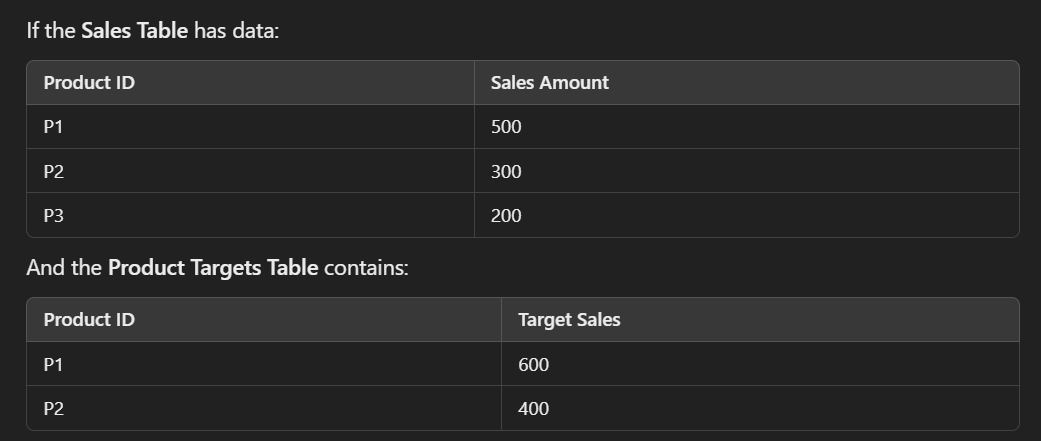

Then, the result of SalesForTargetProducts would be:

`500 (P1) + 300 (P2) = 800`

Product P3 is ignored because it's not in the Product Targets table.


In [ ]:
# If we also have Region in both tables, we can filter by Product ID and Region:

SalesForTargetProductsByRegion = 
CALCULATE(
    SUM(Sales[Sales Amount]),
    TREATAS(
        VALUES(ProductTargets[Product ID], ProductTargets[Region]), 
        Sales[Product ID], Sales[Region]
    )
)

# Now, sales will be filtered by both Product ID and Region, ensuring that only sales that match both conditions are included.

**✅ When to Use TREATAS?**
- ✔ When tables are not directly related, but you want to apply filters.
- ✔ When you need to transfer filters dynamically from one table to another.
- ✔ When working with disconnected tables in Power BI.



### INTERSECT
The INTERSECT function returns the common rows that exist in both tables.

**Syntax:** `INTERSECT(table1, table2)`

- table1 – The first table.
- table2 – The second table.
- Both tables must have the same number of columns and matching data types.

We have two tables:

- Online Sales Table (Sales from the online store)
- Retail Sales Table (Sales from physical stores)

In [ ]:
# We want to find customers who purchased from both channels
CommonCustomers = INTERSECT(OnlineSales, RetailSales)


### EXCEPT
The EXCEPT function returns rows that are in the first table but NOT in the second table.

**Syntax:** `EXCEPT(table1, table2)`

- table1 – The first table (source table).
- table2 – The second table (values to exclude).
- Both tables must have the same number of columns and matching data types

In [ ]:
# We want to find customers who only purchased online (not in retail stores).
OnlineOnlyCustomers = EXCEPT(OnlineSales, RetailSales)

- ✔ INTERSECT – When you need to find common values between two tables.
- ✔ EXCEPT – When you need to find differences between two tables.

### UNION
The UNION function in DAX combines two tables by appending their rows.

**Syntax:** `UNION(table1, table2)`

- table1 – The first table.
- table2 – The second table.
- Both tables must have the same number of columns and matching data types.

In [ ]:
# We want to combine both tables into a single list
AllCustomers = UNION(OnlineSales, RetailSales)


The UNION function does not remove duplicates.To remove duplicates, use `DISTINCT`:

In [ ]:
UniqueCustomers = DISTINCT(UNION(OnlineSales, RetailSales))

If table structures are different (i.e., different column names or data types), UNION will fail.

In [ ]:
UNION(
    SELECTCOLUMNS(OnlineSales, "Customer", [Customer ID]), 
    SELECTCOLUMNS(RetailSales, "Client", [Customer ID])
)
# SELECTCOLUMNS is used to rename columns so that both tables have the same structure.

### NATURALJOIN
The NATURALJOIN function joins two tables based on their common columns when a relationship exists between them in the model.

**Syntax:** `NATURALJOIN(table1, table2)`

- table1 – The first table.
- table2 – The second table.
- Both tables must share a common column and have an existing relationship in the data model.

The `Product ID` column is common between `OnlineSales` Table and `ProductDetails` Table, and they have a relationship in the Power BI model.

In [ ]:
SalesWithProducts = NATURALJOIN(OnlineSales, ProductDetails)


- Works only when a relationship exists between the tables.
- Automatically joins using the common column.
- Cannot be used for tables without a relationship.

### CROSSJOIN
The CROSSJOIN function returns all possible combinations of rows from two or more tables.

**Syntax:** `CROSSJOIN(table1, table2)`

- table1 – The first table.
- table2 – The second table.
- The function returns a Cartesian product, meaning each row in table1 is combined with each row in table2.

In [ ]:
# Creating All Possible Sales Combinations
CustomerProductCombos = CROSSJOIN(Customers, Products)


- No need for a relationship between tables.
- Returns every possible combination of rows.
- Can be useful for scenario modeling (e.g., simulating customer-product purchases).

# Date time operations

## Extracting date from date-time column

### Using DATEVALUE (Recommended)


In [ ]:
Date_Only = DATEVALUE('table'[DateTime])

# data type may be date-time so change it to date

### Using FORMAT (Returns Text)

In [ ]:
Date_Only_Text = FORMAT('table'[DateTime], "YYYY-MM-DD")
# data will be text so change it to date

### Using INT (Alternative Numeric Approach)
Since Power BI stores dates as numbers (where the integer part represents the date and the decimal part represents time), using INT removes the time component.

In [ ]:
Date_Only_int = INT('table'[DateTime])
# data will be whole number so change it to date

### using TRUNC

In [ ]:
DateOnly_trunc = TRUNC('table'[DateTime])
# change data type to date

## Extracting month from date-time column

### using MONTH

In [ ]:
Month_Number = MONTH('table'[DateTime]) # month number

### using FORMAT

In [ ]:
Month_Name = FORMAT('table'[DateTime], "MMMM") # month name

## Extracting day from date-time column

### using DAY

In [ ]:
Day_Number = DAY('table'[DateTime]) # day number

### using FORMAT

In [ ]:
Day_Name = FORMAT('table'[DateTime], "DDDD") # day name

## Extracting time from date-time column

### using FORMAT

In [ ]:
Time_Only = FORMAT('table'[DateTime], "HH:MM:SS")
# cahnge type to time

In [ ]:
AM_PM = FORMAT('table'[DateTime], "hh:mm:ss AM/PM")
# Example: 10:30:45 AM

# Data Cleaning

## combining multiple files

click on `get data`➜ select `folder`➜ locate the path to folder that contain files➜ click on`OK`➜ click on `combine`➜ click on `combine and load` or `combine and transform`

## first row as header

click on this icon 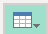 present in header of index column➜ click on `use first row as header`

## appending tables

click on `home` tab➜ click on `append queries`➜ click on `append queries as new`➜ select first table and seond table➜ click on `OK`

## merging tables based on common column

click on `home` tab➜ click on `merge queries`➜ click on `merge queries as new`➜ select the first table➜ select on common column from first table by simply clicking on column header➜ select the second table➜ select on common column from second table by simply clicking on column header➜ select `join kind`➜ adjust other setting as per requirement➜ click on `OK`

## removing unwanted columns

select a column or columns➜ right click➜ click on `remove` 

Let's say we have 100 columns and we need only 10 columns: select all 10 columns➜ right click➜ click on `remove other columns`

## checking duplicate rows

click on `view` tab➜ check `column distribution` or `column profile` or both

## remove duplicate rows

1. select the column➜ right click➜ click on `remove duplicates`
2. click on `home` tab➜ click on remove rows➜ click on `remove duplicates`
3. click on this icon 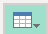 present in header of index column➜ click on `remove duplicates`

## merging two columns

1. select the two columns➜ right click➜ click on `merge columns`➜ adjust setting
2. select the two columns➜ click on `transform`➜ click on `merge columns`➜ adjust setting

## merging columns to create a unqiue column

select columns➜ click on `add column` tab➜ click on `column from examples`➜ click on `from selection`➜ double click on first cell of empty column created➜ then give an example of what you want new column➜ hit enter key.

Note: example should be like `John-1998` here John is from `Name` column and 1998 is  from `DOB` column. Both values are from first row and should be inserted in first row of new column.

## splitting columns

select the column➜ right click➜ click on `split column`➜ then select desried way➜ adjust setting as per your need 

## renaming column

1. select the column➜ right click➜ click on `rename`
2. Double click on column name 

## inserting new column

click on `add column` tab➜ click on `custom column`➜ name the column➜ give formula for column

When you create a Custom Column inside `Power Query,
👉 you use M Language (Power Query formula language).

When you create a Calculated Column inside `Power BI` Model (using "New Column" in Fields pane),
👉 you use DAX Language.

## inserting new column based on condition

click on `add column` tab➜ click on `custom column`➜ name the column➜ adjust the setting as per requirement

## inserting new column based on example

select columns(optional)➜ click on `add column` tab➜ click on `column from examples`➜ click on `from selection` or `from all columns`➜ double click on first cell of empty column created➜ then give an example of what you want new column➜ hit enter key.

Note: example should be like `John-1998` here John is from `Name` column and 1998 is  from `DOB` column. Both values are from first row and should be inserted in first row of new column.

## replacing values

select the column➜ right click➜ click on `replace values`

## checking null values

click on `view` tab➜ check `column quality`

## removing blank rows

click on `home` tab➜ click on `remove rows`➜ click on `remove blank rows`

✅ This removes rows that are completely blank (all fields blank).

## transform column (change case, length, unwanted space, round etc.)

select the column➜ right click➜ click on `transform`➜  click on desired option you want to perform

## unpivotting
👉 Unpivoting means turning columns into rows.
    
select column or columns➜ right click➜ as per your requirement, click on `unpivot column` or unpivot only selected columns` or `unpivot other columns`  

# Calculated Column and Measures

## Calculated Column

**Definition:** A calculated column is a new column you add to a table using DAX (Data Analysis Expressions). It is computed row by row — for each row in the table.

**When it’s calculated:** It is calculated when the data is loaded into Power BI (or refreshed), and the result is stored in your model.

**Storage impact:** Since the results are stored, calculated columns increase the size of your data model.

**Example:** Suppose you have a Sales table with columns `Quantity` and `UnitPrice`. You can create a new calculated column called `Total Price`: 

`Total Price = Sales[Quantity] * Sales[UnitPrice]`

**Use cases:**

- Adding new fields you can slice/filter by.
- Creating fields you want to display in tables or visuals.
- Categorization (e.g., Classify customers as "High Value", "Medium", "Low").



## Measure

**Definition:** A measure is a DAX formula that calculates a value on the fly, depending on the context of your report (filters, slicers, rows, etc.).

**When it’s calculated:** It is calculated only when needed, based on the user's interaction with visuals.

**Storage impact:** Measures are not physically stored — they are just formulas. So they do not increase model size much.

**Example:** Continuing with the Sales table, you can create a measure for the total sales value:

`Total Sales = SUM(Sales[Quantity] * Sales[UnitPrice])`

**Use cases:**

- Calculating KPIs (Total Revenue, Profit Margin, Growth Rate, etc.)
- Creating dynamic values based on filters/slicers.
- Summarization, aggregation, and custom calculations in reports.

**NOTE:** In DAX, you can use one measure inside another measure. This is called measure chaining and is a best practice to make your code more modular, reusable, and optimized.


In [ ]:
TotalSales = SUM(Sales[Sales])

AvgSalesPerCustomer = 
DIVIDE( 
    [TotalSales], 
    DISTINCTCOUNT(Sales[Customer ID])
)

**Best Practice:** Create a separate table that contain all measures. Here is steps:

1. click on `Modelling` tab of power bi
2. click on `new table`
3. enter DAX formula: `Measures Table = DATATABLE("Dummy", STRING, {{"Dummy"}})`
4. Now hide the `Dummy` column from report view


Formatting your measures properly is super important to make your reports look professional and clean. Here is way we can do this: select the measure➜ now `measure tool` tab will open➜ now you can format measure using `formatting` ribbon.

<hr>

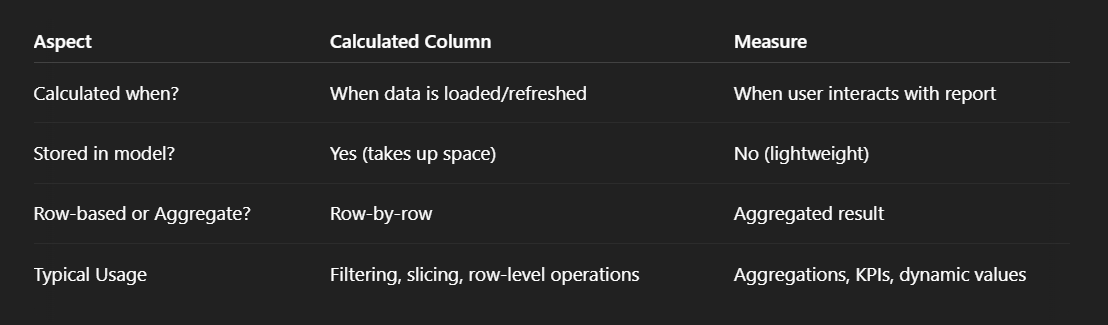

## Understanding Where the Column is Created

**Power Query (M Language)**
- If you create a new column in Power Query Editor, it will be visible inside Power Query.
- This column is calculated before the data is loaded into the Power BI model.

**DAX Calculated Column in Power BI**
- If you create a new column using DAX (like your formula), it will not appear in Power Query.
- Instead, it is visible only in the Data View and the Report View inside Power BI.


**If You Want to See it in Power Query**
    
If you need the column inside Power Query, you should add it using Power Query instead of DAX:

**Power Query Approach:**
1. Open Power Query Editor (Transform Data).
2. Select the avg talk duration column.
3. Click Add Column → Custom Column.
4. Use the following formula in Power Query (M language): `Duration.TotalMinutes([avg talk duration])`
5. Click OK → Rename the new column as AvgTalkDuration_Minutes.
6. Click Close & Apply.

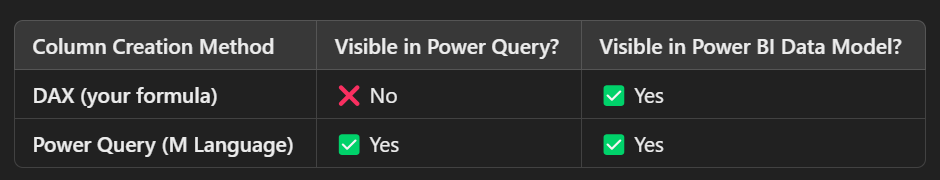

# Important operations

## condtitonal formatting on chart

select the chart➜ go to `format visual`➜ select `color`(option may vary from different chart)➜ click on `conditional formating(icon)`➜ do the setting

## condtitonal formatting on matrix
select the matrix➜ go to `build visual`➜ go to `values` field(present below rows and columns filed)➜ click on drop down icon of column name➜ click on `condtional formatting`➜ do the setting

## page navigator button
click on `insert`➜ click on `buttons`➜ select `navigator`➜ select `page navigator`

## dynamic title based on measure selected

1. Create a measure: `Dynamic Title = SWITCH(VALUES('Calculation Method'[Calc Method]),"Average","Key Indicators - Patient Wait List (Average)","Median","Key Indicators - Patient Wait List (Median)") `
2. select `card` and use this `Dynamic Title`

## handling blank data value and blank chart

Suppose we select some value from slicer let's say we have selected a date for which we don't have avg waittime. In this case we see `blank` as value which is not good. Instead we want to display 0 as value. For this we add `+ 0` in our measure: `Wait List = CALCULATE(SUM(All_Data[Total]),All_Data[Archive_Date]= EDATE(MAX(All_Data[Archive_Date]),-12)) + 0`

For chart, we see empty image which is not good. Instead we want to display message like "No data for selected criteria" and for this we have to follow these steps:
1. create measure: `NoDataLeft = IF(ISBLANK(CALCULATE(SUM(All_Data[Total]),All_Data[Case_Type]<>"Outpatient")),"No data for selected criteria","") `
2. for display message use above measure in `card`
3. palce this card at postion of chart
4. ensure this card is at background so that it is displayed only when chart is not present due to not no data. To so follow these **steps:** select card➜ goto `view` tab➜  click on `selection`➜ now in `selection` pane, move the card below the chart by dragging

## interactivity
When we select some value from slicer then all charts is get filtered. We have a chart and what we want is when select some value from slicer, this chart should get filter on other words we want charts should affected by that slicer. For this we have to follow these steps:
1. select that slicer you want to change interactivity
2. click on `format` tab ➜ click on `edit interaction`
3. now click on `None`(icon) of chart that you want off interactivity with that selcted slicer

## adding button and its action
1. **Inserting button:** click on `insert` tab➜ click on `button`➜ select desired button➜ now place this button at you desired location
2. **Adding action to button:** select the button that you inserted(in above step)➜ now in `format button` pane select `button`(by default selected)➜ turn ON `action`➜ now from `action` dropdown select the `type`➜ now select `destination`(you can choose other page as well)
3. **Hover on button:** after 2nd step➜ select `tooltip` ON➜ now in `text` filed write the text you want to display when user hover on button 

## custom tooltip chart
1. create a new page and create the charts and data you want to display as tooltip and format this page(change size of page using `canvas setting` present in `format page`)
2. Now to goto `format page` (present in `visualization` pane)➜ goto `information page`➜ turn ON `allow use as tooltip`
3. Now goto you dashboard page➜ select the chart for which you want to use custom tooltip➜ goto to `format visual`(present visualization pane)➜ goto `general`➜ goto `tooltip`➜ keep `type` as `Report Page`➜ now in `page` select the page that we create in 1st step for using it as tooltip.
4. Now hide page from by right click on that page

## How to Apply This Theme in Power BI
- 1️⃣ Open Power BI Desktop
- 2️⃣ Go to View > Themes > Browse for Themes
- 3️⃣ Upload this JSON file and apply the theme 🎨

In [ ]:
# theme.json:

{
    "name": "Retention Dashboard Theme",
    "dataColors": ["#2ECC71", "#E74C3C", "#3498DB", "#F1C40F", "#95A5A6"],
    "background": "#FFFFFF",
    "foreground": "#333333",
    "tableAccent": "#3498DB",
    "visualStyles": {
        "*": {
            "*": {
                "title": [{"fontSize": 14, "color": "#333333"}],
                "labelColor": [{"color": "#333333"}]
            }
        }
    }
}


In [6]:
import pandas as pd

df = pd.read_excel("E:/Datasets/pwc-powerbi/02 Churn-Dataset.xlsx")

In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'numAdminTickets',
       'numTechTickets', 'Churn'],
      dtype='object')

# Data Modelling

Data modeling is like organizing your data properly so that it's easy to create reports and dashboards.
Instead of throwing all your data into one messy table, you split it into smaller, organized tables that have relationships between them.
    
Two very important types of tables in this setup are:

- Fact Tables
- Dimension Tables

## Fact Table

👉 Think of a Fact Table as the main table that stores numbers, measurements, or facts.

Also known as `Data` or `Master table`.

It answers questions like:

- "How much?"
- "How many?"
- "What was the total?"

A fact table usually contains:

- Measurements like sales, quantity, profit, etc.
- Foreign keys (IDs) that connect it to Dimension Tables (we’ll talk about those next).

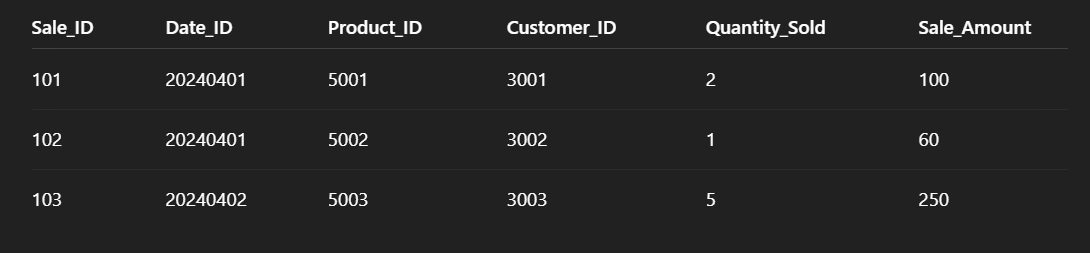

- `Sale_ID` is just a unique identifier.
- `Quantity_Sold` and `Sale_Amount` are the "facts" or numbers you want to analyze.
- `Date_ID`, `Product_ID`, and `Customer_ID` are links to other tables (Dimension tables).

## Dimension Table

👉 Think of a Dimension Table as a description table.
It gives more information about things mentioned in the Fact Table.

Also known as `Lookup table` or `Mapping table`
    
Dimension tables contain:

- Attributes (text and descriptive info like names, categories, locations)
- Primary Keys (unique IDs that match the Foreign Keys in the Fact Table)

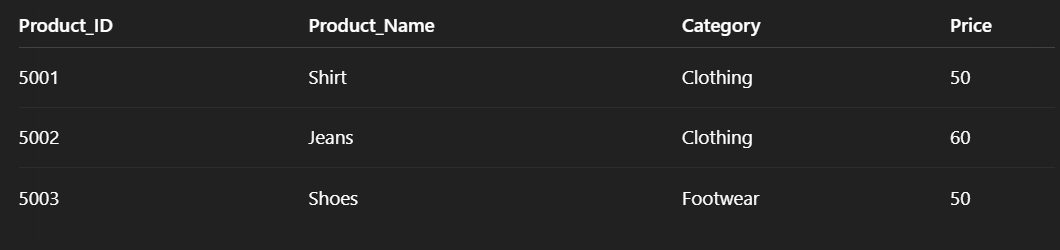

<br>

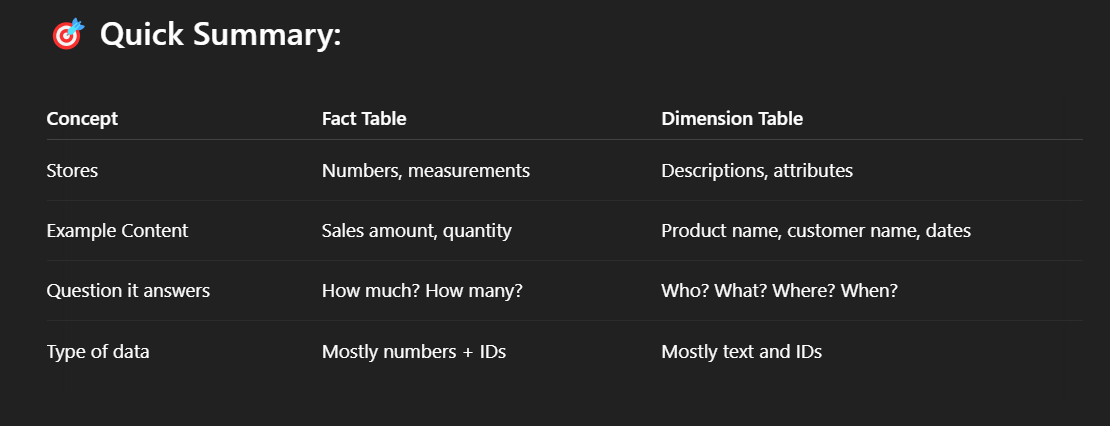

## Understanding Unique and Distinct

**What does Unique mean?**

👉 Unique means one of a kind — something that appears only once and never repeats.

If something is unique, no other thing in the list looks exactly like it.

Focus: Does it occur only once?

🔵 Example:

List: [2, 3, 4, 5, 5, 6, 6, 7]

In this list:

- 2, 3, 4, and 7 are unique — because they appear only once.
- 5 and 6 are NOT unique — because they appear twice.

<br>
    
**What does Distinct mean?**

👉 Distinct means different values without caring how many times they appear.
In distinct, you only list each value once, no duplicates.

Focus: Are the values different?

🔵 Example:

List: [2, 3, 4, 5, 5, 6, 6, 7]

The distinct values are: [2, 3, 4, 5, 6, 7]

See? Even though 5 and 6 were repeated, we show them only once when talking about distinct.



In Power Query, when you preview data (especially for big tables), it only shows a sample — often first 1000 rows. Let's say we checked column distribution and we found that column distribution says Order_id has 878 distinct, 785 unqiue. What does it mean?

- ✅ 878 Distinct →
    - There are 878 different Order IDs among the 1000 rows.
    - (Even if an Order ID appears 5 times, it is still counted once as "distinct.")

- ✅ 785 Unique →
    - There are 785 Order IDs that appear only once among the 1000 rows.
    - (Unique = values that are not repeated.)

**🎯 In simple words:**
- There are 878 different Order IDs in 1000 rows.
- 785 of those are appearing exactly once.
- The remaining (878 - 785 = 93 Order IDs) are repeated (they appear 2 times or more).



## Cardinality

1. One-to-One (1:1): In a one-to-one relationship, each record in the first table is related to only one record in the second table, and vice versa. This type of relationship is relatively rare in data modeling but can be useful in certain situations where you need to split large tables for performance reasons or when you have optional attributes that can be stored in a separate table.

2. One-to-Many (1:N): The one-to-many relationship is the most common type of relationship in data modeling. In this relationship, each record in the first table can be related to multiple records in the second table, but each record in the second table is related to only one record in the first table. This is the standard relationship type used to connect dimension tables to fact tables in a star schema.

3. Many-to-Many (N:N): Many-to-many relationships are less common and are usually resolved using bridge tables. In a many-to-many relationship, each record in the first table can be related to multiple records in the second table, and vice versa. This type of relationship can create data ambiguity, so it is essential to use bridge tables or DAX measures to resolve the relationship and perform accurate calculations.


## Relationship

**Active Relationship:**
- An active relationship is the default relationship that Power BI uses when querying the data. It is the primary
relationship that determines how tables are related and how data is aggregated in visuals and calculations.
- When you create multiple relationships between two tables, Power BI automatically identifies one of them as the
active relationship based on the data model's cardinality and the direction of the relationships.
- The active relationship is used for standard calculations, such as summing values, filtering data, and performing aggregations in visuals and measures.


**Inactive Relationship:**
- An inactive relationship is an additional relationship that is not used by default when querying the data. It is
intended to be used selectively, depending on the analysis requirements or user interactions.
- The inactive relationship does not affect standard calculations or visuals directly. Instead, it allows you to create custom calculations using the USERELATIONSHIP function in DAX
- The USERELATIONSHIP function enables you to override the active relationship and specify which relationship to
use for specifc calculation or visulization. This gives you more control over how data is related and displayed in certain scenarios.

## Cross Filter Direction
👉 In Power BI, when two tables are connected, filters can flow (travel) from one table to another.

👉 Cross filter direction controls:
- Which way the filter travels
- Which table can influence the other in visuals

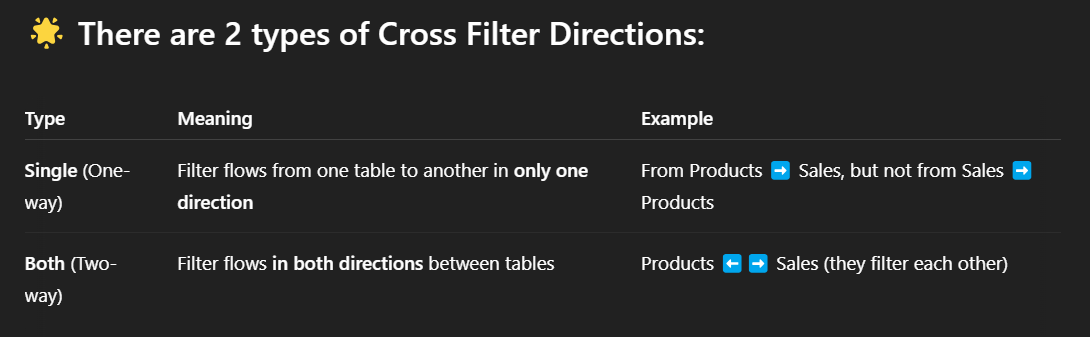

**🔵 Example:**

Imagine you have two tables:

- `Products` (Product_ID, Product_Name)
- `Sales` (Product_ID, Quantity, Sale_Amount)

You create a relationship between `Products` and `Sales` based on `Product_ID`.

**🎯 If Cross Filter Direction is Single:**
- If you select a Product Name, you can see related Sales.
- But if you apply a filter on Sales, it won't filter Products.

(✅ Filters flow from Products ➡️ Sales only.)

**🎯 If Cross Filter Direction is Both:**
- Selecting a Product Name shows related Sales ✅
- Filtering based on Sales data can also filter Products ✅

(Filters flow both ways.)

## Schema

### Star Schema
👉 Star Schema is the simplest and most popular data model.

- There is one central Fact Table (where numbers live: sales, revenue, etc.)
- Around it are Dimension Tables (descriptions like Product, Customer, Date).
- The structure looks like a star — fact table at center, dimension tables around it.

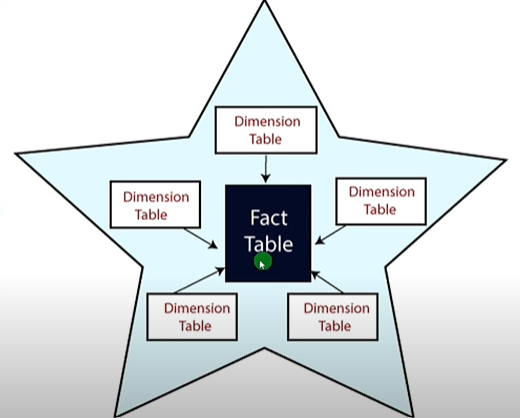

**📌 Key Points:**

- Fact Table stores numbers and foreign keys.
- Dimension Tables store descriptions.
- Simple, fast, easy to understand.

### Snowflake Schema

👉 Snowflake Schema is like a more detailed (normalized) version of Star Schema.

- Dimension tables are broken into multiple related tables.
- So dimensions are split into smaller tables to avoid repeating data.
- Structure looks like a snowflake — lots of branches.

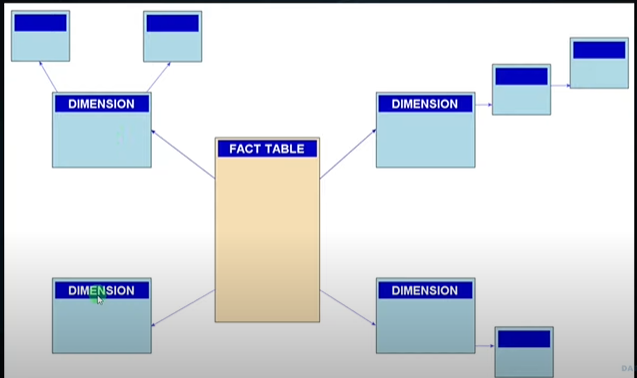

**📌 Key Points:**

- Dimension tables are normalized (broken down to avoid repeating information).
- More complex, but saves storage.
- Slightly slower because it needs more joins.

### Galaxy Schema (or Fact Constellation)
👉 Galaxy Schema is when there are multiple Fact Tables sharing Dimension Tables.

- It’s like many stars (star schemas) combined together.
- Useful when you have multiple business processes (Sales, Returns, Shipments) happening together.

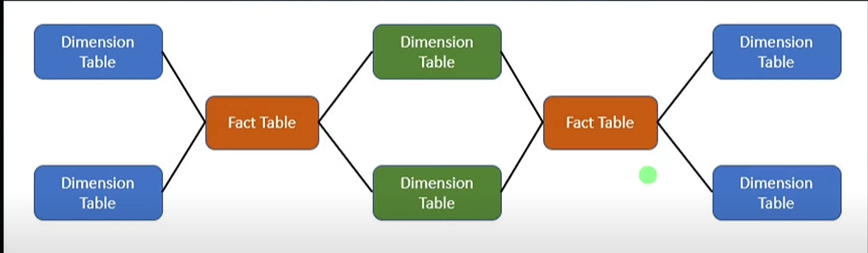

**📌 Key Points:**

- Multiple Fact tables (Sales and Returns here).
- Shared dimensions (Product, Customer, Date).
- Flexible, but more complex to manage.

# INTERVIEW QUESTIONS

#### can you explain what DAX is and how it is used in power bi?
DAX stands for  DAC stands for data analysis expression and it is a Formula language that is used to define calculated columns and measures in power bi. Dax formula are used to perform calculations on data that has been loaded into a data model.

#### how is DAX different from excel formula
DAX is designed specifically for use in data models, where excel formula are designed for use in worksheet. As a result, DAX includes functions and syntax are optimized for working with data in tabular format, such as ability to filter and group data using tables and relationships which is not possible formulas.

#### explain difference between calculated columns and measures
calculated columns are columns that are added  to an existing table in the data model using a DAX formula. They are evaluated once when the data is loaded or refreshed, and resulting values are stored in the table for each row.

measures are formulas that are evaluated at the time they are used in a visualization or in a DAX expression. They are not stored in the data model and are not associated with a particular row in a table.